# accDM upper grid: live progress and updated maps

Notebook odczytuje wyniki kampanii **Stage A: 1122 punkty górne + 4 kontrole**. Nie uruchamia fitów ani CLASS. Wystarczy wskazać `RUN_DIR`; dane odniesienia i 30 wcześniejszych poprawionych fitów są już osadzone w notebooku.

**Uruchom komórki od góry, a potem wywołuj `refresh()` lub użyj przycisku Refresh.** Odczytywane są również ukończone pliki punktów z trwającej rundy, zanim pojawi się zbiorczy CSV. Licznik unikalnych punktów nie sumuje tego samego punktu z kolejnych rund. Osobna tabela pokazuje postęp każdej rundy.

100% zapisanych punktów nie oznacza znalezienia minimum globalnego ani zakończenia wszystkich rund. Szare oznaczenia na mapie wskazują punkty bez nowego wyniku; poza nimi mapa używa najlepszych dostępnych wartości. Wartości dla brakujących pozycji siatki nie są tworzone.

Jeśli notebook działa lokalnie, skopiuj z klastra katalog `stage_A/`, w szczególności `campaign.json` i `rounds/`. Sam `reprofile_best_points.csv` pozwala obejrzeć ostatnią pełną rundę, ale nie jej późniejszy częściowy postęp. Notebook nie pobiera danych przez SSH.


In [19]:
from pathlib import Path
from datetime import datetime
import base64, gzip, io, json, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, clear_output

def find_project_root():
    here = Path.cwd().resolve()
    options = [here, *here.parents,
               Path('/home/2/ks405818/Master/lyalpha_one_loop'),
               Path('/home/krzysztof/Workspace/lyalpha_one_loop')]
    for path in options:
        if (path/'accdm_upper_grid_fit').is_dir() or (path/'runs/accdm').is_dir():
            return path
    return here

PROJECT_ROOT = find_project_root()
RUN_DIR = PROJECT_ROOT / 'runs/accdm/reprofile_upper_v2/stage_A'
# Lokalnie możesz wskazać kopię wyników, np. RUN_DIR = Path('/twoja/sciezka/stage_A')
EXPORT_DIR = PROJECT_ROOT / 'runs/accdm/analysis_upper_grid_live'

UPPER_ONLY = True               # False: pokaż również dolną część mapy
COMPARE_TO = 'campaign_start'   # 'original': porównanie do fitów sprzed poprawy 30 punktów
REFERENCE_MODE = 'original'     # 'current': wspólne bieżące minimum dla obu paneli
DELTA_CHI2_MAX = 25.0
DRAW_CONTOURS = True            # Kontury robocze: 2.30 i 5.991, bez wygładzania
MARK_PENDING = True

plt.rcParams.update({'font.size':10, 'axes.titlesize':10, 'figure.dpi':110})
print('Campaign directory:', RUN_DIR)


Campaign directory: /home/2/ks405818/Master/lyalpha_one_loop/runs/accdm/reprofile_upper_v2/stage_A


Osadzone dane odniesienia pochodzą z zaakceptowanego snapshotu 1600 punktów i kampanii 30 punktów. Ich tożsamość jest porównywana z metadanymi nowej kampanii. Poniższych komórek pomocniczych nie trzeba edytować.


In [20]:
# Frozen reference data; this cell does not read or modify production inputs.
_BASELINE_GZIP = '...'
_SEEDS_GZIP = 'H4sIAAAAAAACA6WcaXIbSZKF//dZIFjsywXmGrRcIqtkoyrJKFb3zNgcfr4XIMXcWAOwZUYKfEBmxvLC/bmHB16G59/ay+Xb99+s+eNpmKbby6W/nH7/6p6+f5tvL8b28+Xy2/D1z9ufz21pz+3PqV3m9u1lePr14dWf/ZKf7VubXtr89P35629c/c/h29d5ePn6/c+nny/Dy18/L99/vHz94+v/bLDh5aX98ePl52X8a6aFT+2/fh/++slt3j7dnp9+/jVN7efP9vPy8nv7/vzfT/PX3/TEH8Pz8Ed74RO054kOPQ3ffvw+PP3H6h01bfPWt+//Al4jf/34sUO2Nx7by8k9X9Hb7V7/uN3p8Hnd5Hbr8evwc3+j1Tu3m62A2w1Pr/3VsrN7vr+xat/qjmcXvrdyejlv4/SyaSF/rts3vZy17nivN3jVsl93evurs2r5/vyv4fmNlcP0n/2v+eszNOsM+vHchvkCkcav376+/PfTII78/KP9+XIZfntuTa+eXr5/a88D/P2HDddsgyuR3/5/v9irz9Hc/l02711u712cK9fi+VesTyHF6C+22msNLtXoizOlhnjx6VqqScHlGHxOJoeLLeUaXI01h5SM5dUlmGswPgeTsgnRxXLx12i9qblarkmRN1eU/+fXn1+1CF4XEa+m73/8+Na0vn4tmXIx/JR5HgeaGV3LIS8xjuPsS01psnW2c3U1D2UeTBqdiYuPNi3DkGIxxcaWQrh8CdeY6E7x1ngTjS0dsoZ70N9Mb2tlTCyYqy6GFGo2ztWLuabqbci2mBgrg+Ev8ZoZr8wQpRx85V7xanxwDF5kaHkCD7Tmai5Ov774q48MB2NZQrU+FEE0uYTiGScGJsXLl8JH9WO5l/M+0TjGzJTEWF+Dpem5MvY1R8vd49vd3ZWWR+5Qq6E71ob2peTLF96jbdHxzOSY8RicJh0i6Bm3/77Qh6t3DJT1/LhULgApBsscJq5kAPfXbNkBKU4Qfe6dnd/Hn+35n0zqn99fnn779n0cvj39eP7+fdHn7D/UlV//9pRVN9+Y6u3VhWjgVi2e7kae7K/MUsoMo0nG1XTx+aqeMnkh58isnhLVXSFGyF4jHTLT53idYy0hVp5bPsdS1+bJ+rHVNgxtTIFVFaec5xLcsDg72iH7mbeHoY7BjyyJ2YdqYp3rNFpjbyyN0I1m1QK9YrzRFMqquZZeO/sATV2EM8Umm0uqTjR1zkcTsyaL5bynafKVeSw5JQ87O2SiczTS2ZKyZW7XPHUBboVSa7IpQy94akq2lvWVk7XGrYnK52mbsxgIVwK3LCuilloYdp9yzXTshKfp6r0JIRibaFK6hHBVRxK9zq4Yf8LTDTdY/WfQY0yt15v11O//ZWLeeXvZvKdJu7XAeQYvW4aU+TsgiYGMLD8Wt6vWWWdc+2LPbeu1GMdIZ+9ysNmnHYJxjZ9j7TxOk3i0MC9Ljq1FO7YxQrbUZviLfbAZRjU/YVpN9MNo4lhsnaKdYuusZU5oiYXKLpm0gZJPjjm6n7Q3kvOapRlDPUG2pGU+Md+5YH6xsPEUeudsgOPFZHoUsADen0Er0nZ2siqgXcR4Y5iy34Ax41JKTN3iv9KP375e4Xi2HrbbGjD5b0j8hWwuOFLjiDxG1q0SMFe7IutWCfDexUXah4OiLzI1OV+cRgGvFeXstFz7oqO7MUFVrERi9Z4wNctcV+espEMKGbuYrrHKsJXsuHW1jxLVWpjKr6HV5CcsRB7wc3aYfR3nBcszjiKZNW1udTZpqXGs4zJghorkylSyH4wbxQ1o7cUMl42vGOhu5GyV2cd4eWPv52rAH9nkDLIm46rLTe8wVBlPyFV5Z2ANugHzUxjnYLoD4q6MdpJhk8/3RUb3jaxfKsaBDhSNecC1ywrg/uSkmDtG09Y1V/lBaqVQ4BePgdGyigY7WXurLHeLZse7LxYFUGKBYfgD+hLlJnLgGYWr0B20M26vWTEjWJRe2SEJNYAu8cnCeAxGwpFlj2WzD9A3bVQBvVjRN91Gkxmg9Rlnz5gmpy6fIL3dR5ri1Zh3GGJ9TaJlOIPGgZDv65/t7/kZoSeTU8w0Dw1LitFp+EXfytiS8UubS15K5c9pmhZ8/dwCVKaVzrmx2TAsJs1iYkHcYBxiF+S5nkL3krPI02bEkjO5amgOyJqcDBuroiAPYoJdNp9Cb9xE6TO6+H/vu6Jl8ZxiG3ri4OTjEssDcsGxU2zv++21oGJxeQgK/EAn4wm0ueheXjxCxzeD6eqRju/vvfIyMhjojKqwouACwwWBjaeBfqgxBSD1Up2UfvYYi8pawbGc0TTpUxhNBBvrlHbbrIWOgEGl40ZKfdjv40n4aYQL6C0Mfy1TmeMyzGGcaGFzuTW1KLnYMDy5LiOdwd7yQeItU8aK5hI3ies8FiLAKjom14mFQvdVXD/OFAcQ7uerxZcyDBiUxFtB1o7uGeQkT0GqV7uzplyGOiHcItBLRnz2XIGlJODBO0GMlVy9MZGLsIGQXzY4hX7RxoLGCKdQAshXHEUUTRzGGpPGo5BbuJ2dq/+Sr/QrcBmTos8kERQTmFm53CG43uWtPFiRQezH52wghk7rFZnOJBA+BMfKd+FhE7qWq3vOruWqOIucpiNIGXQ2cggYZXotKFMmmLCaSb4UtQlHQatYsDacCgDeZFkTnUdsh+GT4ZKzJktRDc4ExuTPUXZ2ieCqzDVOYcLMTB7C+qHlOORpcnlZPCZuXPLimnFT88NCUythl8HE5rEHUyw9g+/MAQftulR1GDmcsUtYWS3DOxnrWOJ41YycyKxCNAZTRkDiCGMQwXDfbLQquohA3UvOOV9Sj1lYLoqcEPIoW8PIvBNWlp8BxA1Zy+hm6T/HR3rgQi+UTck7rYofxvPDYUL3pGZ1+nrPwyTDsbJyajtnjn0xBJtaFokIGrNvK8sJPUKzNCY7ybChRWWi/R4ipqW31idWIY1ELdJqCQD/EHvfjGpJR/a+v3djrxQI6501xwpE1pUT5CMlkK74EluwYU7rN5Yz6BElgMrKkj3NLhPhVFxmBcqTWSYTxnFxo2HJEzYME/qboSb+Hcxo8kx0jtJfxAu6C//wcLiLnoY5ge61rHQX7YBBZrh49AmyNqxY4tqTfEXuPMd6Cr0rARYUHh8PJcUre+fPwZ0W8HAO4U3IQbRh/Cm21wKIykrkicuEZ4xgyufY9rJ7ufEIN+OvAOrIzff3Xrlp/JXQihHMTBdKJB4hRHcq2H/4mTS5H2cCCN6UI8J8IYKUOEgHKDxqXm+0NXb2yim0sLg0hYXJcGnG+9chTnEckFzT7MMwDHFe3JDRCaUtcWkpL5mP3DhacbCENOho/PYBMg8I2FplQJSpqUm29IjsaEtgSniFQSXOLPYUWtGWKDUz5Ng+tE7M9QQrW9Iq2MO4OkkdZsnmA8aFJ6StrirmN3QwF7n2PZb9QfceGXJEHiXtNiGwJe02ISDSIr/QHCwuFj1jF/ZQlkRhvToJAkQb02K7jT/VBDi6rmQYL49/2kPyb58irW1eae+6DIMd5mlp1o4tE/27ufoljAvtRL3JG+YJg5sXA33djOANeUo30jKFVWGrkus5H6EeYdzLWsufmh9MPiN2guxZ67R/4Y12E0w4hd5ZayUtImohuoqCsEfIxB1pmWDbk7J4f9y122Mlp2PUJW2PeOOuhC8sIS3lLRZMPHJ2T5Aj8ihnf6lUe+Ts+3tvIgDRVBgVrUOMV5Wlx68gejIKBJnNDPmrXvlCIFDoek2nVtbFq7ZMtK4JgwzCXkqJi0rW7ghqiuX+ORU7tWmAWTBJKi1pM2PKZSa4GJYJihQ7ujxLN9DqMBIKhQlPGlqaJ4jb1QFWH4+n1IwsgunbBDRIWxqorW4j7mdsVuI9uyiZxoAIiVyEfcPIZfxK3AVefZcnFtuTbiLeq0LApXZbGDcK4S3yUphLc2kRQY6pO0FglGEkqMWLy5MFfzPHhGrYfAwyKiX5A+O+cAe8v4tMB6uMICUKQ+k65Heoyoa5E0GwIkXfmttBAdd3atzcZzNYZrNZkG5dviAwxSlttzBt2dcT5APVmny9ohYYFRcjA3oE7lOsrEj9xDY1My5+mAcf2uTrFOeJ4fAN6TraGBnQqY1uGeM0xjEwJ4QthFZmGaICfw//eDALj/C9KnI+g+6lJC9RgGhhNANO/wTZ5q7gbmHaDJMNk8+QdxOKv0VEKPxj6YXu9w/QhprE9gxEhvVqKBQ/xY55q6gNAtnZnvnugdcZtrnsXkZ8MnO1p+EqcaW7plwZuKhtE4k2fwQ+YGOo2t6LCu+DKgAUZByhR2Io78c5K6Qk4h/nhvHDt00LxIlmdrks8zjBSHxzGN1IU+apJ25LmOsYY8+mJm0XIecUzzp/htzHR48vwNZZfapk0xP9e2S3KeW6hcd7WB+1DXACvTNS+0cmMrU4VYxWPoM2jMQB48JgtrZrTE9mHqBdmv/adxmSDaXSYi8ReoqtLrqPDZ/MR+2ZuEpH9Qyu08ZFdolhYBS037lDVBaRTcThxaQ8CQMVPpKfqh2oylHSUYJM/P8BCp/Un9NMdOvHNtvJzpChDEtoeY52SksaeDmWxRNlT2UhTBrjMhF5z3aZiLHwT52nFV3lbdYAZAidj5gP93M1KmealHepOHV/Cm3ZWvQE1po4zfP9OfbO18RYIwoZtsgS6PH+AdrwNSc0We37/2iqUA/QyZ6/0mUS4dF3exn6ZtcO84do68iSI/Ioa1d5qD1rV2moW2oMx1NNNjXCLMTTCfKBBc09WLXWWW2j094T5H77Cb8XohzEYJuxkX6qUxpDG2az5DJon370tQ7Oz6XO05CmFn2dx4WJ9mUYTWtd0kUl8vG2vZfpFLrXoysnqU0nFpsnGjtBdmFRiLJLSnSq6OMUWoVFRvujthBqJWyBjafYjpOq2XKKnIjd+8QcoK0N5QP0GYevjSrt7KdzbJssvY8Rn8w97fm4Sj3dhK67YuGIvPoGXk3xDPooL4oA9kXFY4qAEnN7Bj3i0xcumOZRaaDZM5MTtmisgzU5L1jIVicEpp1iiWMrzhKsNsKfERk+DT43fwszArGD9pa111xPobtDda94MqSqijcXTpB9qE58gqHjgTKKp9CvqAcCeqfCAqXDq4Xp7gNwzUoxMBLcaUvC9Jz/Htlzsqi6D9UflM2s3p1j25T/vaz4ZHJpz8pVbuktTaDaSSQ3Ky2rQucAPZAPjdrX1jaEdoIZUbuHSvhsQnSxsxlSasFNcamYh5lQNPRqPTcPtZUhSYA23+zYpjEvQe8PsLfkMXSjhUvEkdOjng89ge6vjBIz6Tz/EW+4M2SfxneqctGOnYknwJqqxNaWKBuh0HeCzrBdMhRDiUQpzBB6Vltae6yUExUaPKwsrJbqjXIoR2y/P3VgxhH5N3JKe6quUkq3p0f8CFEDfjjTvnpAin+Aquma0D1Rxb2hmBr2SOFun8uC5rAk60zTfkarS2vRzdMUCiwkhJ/yYFteTAvDQLuxuHbBLw5JO4xTjbdtUNX/VFUj1mJvOZ0t5B+wrKr0VDoH9VJPkS1VoaU2owKCM+cUT6EVXaE70T3rqKqEgcUUz9CYdntOofRdLBVKYxayO2AniVCcdd9ArU51p0V58B1W7XGn6oQlJ9CjddIf8jbuecviuMqBMnbMcAI9Ih+4fV5ftZ+Nmsdc4AdPkIfKoqwfcyX2mWydIKkZmKFhaS6PE/bPDEsGbK60yZXRTDBumZuqZwoObx560R7LnfA/qN0qqzjH7iVnCNWpxgKzQxBxBLapJUaFYTW38nDnTqFVaBS1H2ShFe76FhntkA0lVT3TK0sJa1QBeAYdAnm6weJNWhuqzv0AW110Lxs+X1wa/qa4VBtHmDmjKh2mNRH3gpgrfEpMSVW9WLykK9GZagezomUZwjMDWq6WG7Ba0f/WBxw7woX1hz82WD781CeT8ss4ZTNm5XtTnOKMFFqmsYY51ua9Wxa3JJlWX8yci/ezadiLMPgwqRi6745Ah1B17sVrL6b0MDorMe2BtQWVU3qkHIpYhAhcu0ZGJzOuuBhvVJWAebNpF8NH1YCLAaq6xP1qokpMGV5kgzWESnZdCO2QKFl74B4/RHOAlSpXwRKmvvRDM9s6aGJuZqZX4UcxtO+5gKiMUTlWVV0f7Cfh69X1cIeA3RU+e8loYO0DqETLasiOxvNjuoDWJGK98QWni3pgfC/LX88vv+soXRuep9+f/myEvvMHfHV/w1fttGaVXTLvljBNu+pn0Af209arV+IcZaLqvGr8GfSIBR2I1odo52ku01BGWFprS5oL3+aQhihuDqOXW5+IKfJsXZsXZEULwbZe4szTNeYp+frqxM6we1NMGXoj+YhLtOlY8xm0oqeKIVUTrrNR2geI1Z9iv+jZN7h0TCPANo3uCbJlJz7c3rbFO6H9ObY2ivFKtyWGGSerascTZKdE72XFJ+3o1qeHQ9jkyjUT6eqIRVCJnj9ASccZVHmvrcOISTQf50SDXA1mQZXksk1lj6RPRk0pD6OpNsx10IGSpQVWbBuX0Vt+cpkJ/7H6gy+pzWZqLSjMKn7x8xKnpRc9W50IqjKBAYPj0x7TuZL76QozZWugDrZQJmgF0ZZt/ZNREqVAF9WhZtnfLVSqW2/J94yIYkyvUwQhxzUCLXyte6rafv6JWDtE05OxW8w695pFWtnEjDXHlnZZW1X3u0ZqH5CDGf3/+ZL9v5MM3fn9fVFeuOXYc1aQgbp2t0QDrgeWKTC3Jsq0X+WjUrcAOoRwWlMa5OD40xBt4+hUp+jcVQE0/gOZGKz5ZBk0QZBc+GBnN0xtZNJaqQZDVjCebcnjHIY8Oojg64irmYY4SL6DzXnJtwonvD4xMJ9A6NXbXrzTHl+WBUpSiHdTNXZ5U/sRTOMUOHU3mVXaiTyNW6qy5HGulttYFbn0MkEdFbXKXmUd2Q1xzVVbMblZlRDy/0ovWR0tcNEqGRlhk9uXlOp8is6mRISH7QUcVmE67Uzdbpuys5N0teLqsD34FCUb+n6GM/ST8eEZqP7o9ympFS2QH8i4LcQEyMsYZeZClzhe7u/Rgugte93fsBcVUGFYP6XBI9FGJvUTIlk7GMHcqkzQIUjSSGt6PpTg9ly3qgwG96V0t+pkabVPWvTazmSkCuhnTu+lS1vmZfYpjJZoP9exuMGUIWBMJxPyAC3aXG0bYrOzHeKMgER/TMs4WrsMuZM1yUPivXRiVrlCpVcgn45DoV11uviBQycl6vBtNDqMnNMt8NdZZp0ksa/5y/eK6OB1KM7HXurE+rmlx5xO1OGzGZZe8/EeXikdgCUJKoqBxuEmTFPpJcaMJa7r5rfXBVBKzCepB6czr93mqcJE9cn9VHWoh7Sq5IYOVwTxXKcbepAVrSI+zxiqNHt/KmrNDYKTFHcQ7es5u8oYQQbL6mDG/k0K27+hsL04XLpOcRnsQdU5sHCAgv+oVPssN0Dsq1PhfFx7NojuHYJforXL12/04OfL8Pxy17aAXZYllqEuZrKQE28wjIsxc8XE1mUc0uLTHHXO0hJ9VTuUZjDVddAxq/k1p8rcqBSJIQ35gKRHyqHorsq3Cy90DOKI7NKsGFKdmSi3DadTaFV2alRWVvtBSy2xXvl8Am73+7GCinJRvlaVa3uoH9bepQlQ1TrBj8HFhJme1jjD1gw+UuMEelTgrgv49t9HsS7gu53yp1dX7IFKxhGhymocICmEuxmr8uOoGnevGlbVc+0gOexPyVxPvDWVqRJnYW2Tcqlzm5YIi5stIw9AKGTMssQNMdukrmKIQ5jCUrN9/QKKrMIFefxcNghxYr6VWN67O6DKb6/6eUYoug1iVGO8L1GpOeq4vnJMUGgL4dFidZuD0/1MlsdR+P4lBCskq6jGH/IF+H7f8wkVm2ld2YCoiayv39gZ0QAn9AB8ImxTsdMWSYdj00duHKHHKJv/5qhfPhz1s1XfRMBAZ6VBjPaaTqCPcq1XRKOO/9QkYVP9CfJIpqAFphuSDYpWRuWPBmRAnPOEesSnzqzgeSYw823KwzKMzcHVqM3WbOfQfX/fimBF9VPgrxX8e+huNSDhaLWDxErtm/57ZFdYWlTMHFQoJenqzrFtYen691stqZKhxIkGSaEvQamn2OFLJjDDrBijEkAUsgh7Au2/ZeLe2f88/9zf8M/xuHxVPVbQ0s3dXG4AFWErs6cEhWJpo0OPH1nLqjLcoPIxLW2c+hYJ+u6ZTxnLukALrJ4LyxCWmWGp2lnlR5UTDcenrziYR6KeEam26NTg6KudFhMmU3o1itfZp9oPCmPx6xoSN6H2A8REREYVs6us2OZ3RMGTCod3xLSEG8qV1aIzoLaUNUgkpDRCPTJTJ1bW//bnSUzo24C6Xod57QrzhJhodVcOyhSJECVueqLmFm6+QqoHrwqqdzZyR4h0Bj3K0Y+PlubD0VItCbS8UWGNFnI4QT4qc74q9mKkJbkT3TtBHtqNIgTKCxJySJPPdsEDEQUsYcaPDSirOeU2a0u21mFhYGKdFnxbmmBrGeLNHOKQjMhjs04bnEJ3EzGWrDNHSpNgMk6QLRG9siZRbGd1xl56fwq+M9Er0YrYwZsScvTvhDjF1vYTeQg5okUl9jxGOAe3zCxXNaEbCbXc51Noy8z7ePF5Xrq/4aXrT0PaOqfvNcMCvVrvHfSx7+5lUK70j/WvV9ojjxTs+Wke9FUPwzgvVflTN/qSlymbIRIhpeQI8MdpSKCDClsILGaoyuu5ufRKQ0OYmzBQeLnbCbgDdL/vZgT4gL58Ipd8gux8N35dKb4UxKlkz7H/33erngrqW325Q7p9680eOh4CKWqbVQeN8ken0NFz3zf3d7LP+H/8H0m+aAGCUgAA'
BASELINE = pd.read_csv(io.StringIO(gzip.decompress(base64.b64decode(_BASELINE_GZIP)).decode()))
BASELINE = BASELINE.set_index('coordinate_key', drop=False)
SEED_BEST = pd.read_csv(io.StringIO(gzip.decompress(base64.b64decode(_SEEDS_GZIP)).decode()))
TARGET_KEYS = ['11.0000000000|-1.6000000000', '11.1428571429|-1.6000000000', '11.2857142857|-1.6000000000', '11.4285714286|-1.6000000000', '11.5714285714|-1.6000000000', '11.7142857143|-1.6000000000', '11.8571428571|-1.6000000000', '12.0000000000|-1.6000000000', '12.1428571429|-1.6000000000', '12.2857142857|-1.6000000000', '12.4285714286|-1.6000000000', '12.5714285714|-1.6000000000', '12.7142857143|-1.6000000000', '12.8571428571|-1.6000000000', '13.0000000000|-1.6000000000', '13.1428571429|-1.6000000000', '13.2857142857|-1.6000000000', '13.4285714286|-1.6000000000', '13.5714285714|-1.6000000000', '13.7142857143|-1.6000000000', '13.8571428571|-1.6000000000', '14.0000000000|-1.6000000000', '14.1428571429|-1.6000000000', '14.2857142857|-1.6000000000', '14.4285714286|-1.6000000000', '14.5714285714|-1.6000000000', '14.7142857143|-1.6000000000', '14.8571428571|-1.6000000000', '15.0000000000|-1.6000000000', '15.1428571429|-1.6000000000', '15.2857142857|-1.6000000000', '15.4285714286|-1.6000000000', '15.5714285714|-1.6000000000', '15.7142857143|-1.6000000000', '15.8571428571|-1.6000000000', '16.0000000000|-1.6000000000', '16.1428571429|-1.6000000000', '16.2857142857|-1.6000000000', '16.4285714286|-1.6000000000', '16.5714285714|-1.6000000000', '16.7142857143|-1.6000000000', '16.8571428571|-1.6000000000', '17.0000000000|-1.6000000000', '17.1428571429|-1.6000000000', '17.2857142857|-1.6000000000', '17.4285714286|-1.6000000000', '17.5714285714|-1.6000000000', '17.7142857143|-1.6000000000', '17.8571428571|-1.6000000000', '18.0000000000|-1.6000000000', '18.1428571429|-1.6000000000', '18.2857142857|-1.6000000000', '18.4285714286|-1.6000000000', '18.5714285714|-1.6000000000', '18.7142857143|-1.6000000000', '18.8571428571|-1.6000000000', '19.0000000000|-1.6000000000', '19.1428571429|-1.6000000000', '19.2857142857|-1.6000000000', '19.4285714286|-1.6000000000', '11.0000000000|-1.5250000000', '11.1428571429|-1.5250000000', '11.2857142857|-1.5250000000', '11.4285714286|-1.5250000000', '11.5714285714|-1.5250000000', '11.7142857143|-1.5250000000', '11.8571428571|-1.5250000000', '12.0000000000|-1.5250000000', '12.1428571429|-1.5250000000', '12.2857142857|-1.5250000000', '12.4285714286|-1.5250000000', '12.5714285714|-1.5250000000', '12.7142857143|-1.5250000000', '12.8571428571|-1.5250000000', '13.0000000000|-1.5250000000', '13.1428571429|-1.5250000000', '13.2857142857|-1.5250000000', '13.4285714286|-1.5250000000', '13.5714285714|-1.5250000000', '13.7142857143|-1.5250000000', '13.8571428571|-1.5250000000', '14.0000000000|-1.5250000000', '14.1428571429|-1.5250000000', '14.2857142857|-1.5250000000', '14.4285714286|-1.5250000000', '14.5714285714|-1.5250000000', '14.7142857143|-1.5250000000', '14.8571428571|-1.5250000000', '15.0000000000|-1.5250000000', '15.1428571429|-1.5250000000', '15.2857142857|-1.5250000000', '15.4285714286|-1.5250000000', '15.5714285714|-1.5250000000', '15.7142857143|-1.5250000000', '15.8571428571|-1.5250000000', '16.0000000000|-1.5250000000', '16.1428571429|-1.5250000000', '16.2857142857|-1.5250000000', '16.4285714286|-1.5250000000', '16.5714285714|-1.5250000000', '16.7142857143|-1.5250000000', '16.8571428571|-1.5250000000', '17.0000000000|-1.5250000000', '17.1428571429|-1.5250000000', '17.2857142857|-1.5250000000', '17.4285714286|-1.5250000000', '17.5714285714|-1.5250000000', '17.7142857143|-1.5250000000', '17.8571428571|-1.5250000000', '18.0000000000|-1.5250000000', '18.1428571429|-1.5250000000', '18.2857142857|-1.5250000000', '18.4285714286|-1.5250000000', '18.5714285714|-1.5250000000', '18.7142857143|-1.5250000000', '18.8571428571|-1.5250000000', '19.0000000000|-1.5250000000', '19.1428571429|-1.5250000000', '19.2857142857|-1.5250000000', '19.4285714286|-1.5250000000', '11.0000000000|-1.4500000000', '11.1428571429|-1.4500000000', '11.2857142857|-1.4500000000', '11.4285714286|-1.4500000000', '11.5714285714|-1.4500000000', '11.7142857143|-1.4500000000', '11.8571428571|-1.4500000000', '12.0000000000|-1.4500000000', '12.1428571429|-1.4500000000', '12.2857142857|-1.4500000000', '12.4285714286|-1.4500000000', '12.5714285714|-1.4500000000', '12.7142857143|-1.4500000000', '12.8571428571|-1.4500000000', '13.0000000000|-1.4500000000', '13.1428571429|-1.4500000000', '13.2857142857|-1.4500000000', '13.4285714286|-1.4500000000', '13.5714285714|-1.4500000000', '13.7142857143|-1.4500000000', '13.8571428571|-1.4500000000', '14.0000000000|-1.4500000000', '14.1428571429|-1.4500000000', '14.2857142857|-1.4500000000', '14.4285714286|-1.4500000000', '14.5714285714|-1.4500000000', '14.7142857143|-1.4500000000', '14.8571428571|-1.4500000000', '15.0000000000|-1.4500000000', '15.1428571429|-1.4500000000', '15.2857142857|-1.4500000000', '15.4285714286|-1.4500000000', '15.5714285714|-1.4500000000', '15.7142857143|-1.4500000000', '15.8571428571|-1.4500000000', '16.0000000000|-1.4500000000', '16.1428571429|-1.4500000000', '16.2857142857|-1.4500000000', '16.4285714286|-1.4500000000', '16.5714285714|-1.4500000000', '16.7142857143|-1.4500000000', '16.8571428571|-1.4500000000', '17.0000000000|-1.4500000000', '17.1428571429|-1.4500000000', '17.2857142857|-1.4500000000', '17.4285714286|-1.4500000000', '17.5714285714|-1.4500000000', '17.7142857143|-1.4500000000', '17.8571428571|-1.4500000000', '18.0000000000|-1.4500000000', '18.1428571429|-1.4500000000', '18.4285714286|-1.4500000000', '18.5714285714|-1.4500000000', '18.7142857143|-1.4500000000', '18.8571428571|-1.4500000000', '19.0000000000|-1.4500000000', '19.1428571429|-1.4500000000', '19.2857142857|-1.4500000000', '19.4285714286|-1.4500000000', '11.0000000000|-1.3750000000', '11.1428571429|-1.3750000000', '11.2857142857|-1.3750000000', '11.4285714286|-1.3750000000', '11.5714285714|-1.3750000000', '11.7142857143|-1.3750000000', '11.8571428571|-1.3750000000', '12.0000000000|-1.3750000000', '12.1428571429|-1.3750000000', '12.2857142857|-1.3750000000', '12.4285714286|-1.3750000000', '12.5714285714|-1.3750000000', '12.7142857143|-1.3750000000', '12.8571428571|-1.3750000000', '13.0000000000|-1.3750000000', '13.1428571429|-1.3750000000', '13.2857142857|-1.3750000000', '13.4285714286|-1.3750000000', '13.5714285714|-1.3750000000', '13.7142857143|-1.3750000000', '13.8571428571|-1.3750000000', '14.0000000000|-1.3750000000', '14.1428571429|-1.3750000000', '14.2857142857|-1.3750000000', '14.4285714286|-1.3750000000', '14.5714285714|-1.3750000000', '14.7142857143|-1.3750000000', '14.8571428571|-1.3750000000', '15.0000000000|-1.3750000000', '15.1428571429|-1.3750000000', '15.2857142857|-1.3750000000', '15.4285714286|-1.3750000000', '15.5714285714|-1.3750000000', '15.7142857143|-1.3750000000', '15.8571428571|-1.3750000000', '16.0000000000|-1.3750000000', '16.1428571429|-1.3750000000', '16.2857142857|-1.3750000000', '16.4285714286|-1.3750000000', '16.5714285714|-1.3750000000', '16.7142857143|-1.3750000000', '16.8571428571|-1.3750000000', '17.0000000000|-1.3750000000', '17.1428571429|-1.3750000000', '17.2857142857|-1.3750000000', '17.4285714286|-1.3750000000', '17.5714285714|-1.3750000000', '17.7142857143|-1.3750000000', '17.8571428571|-1.3750000000', '18.0000000000|-1.3750000000', '18.1428571429|-1.3750000000', '18.2857142857|-1.3750000000', '18.4285714286|-1.3750000000', '18.5714285714|-1.3750000000', '18.7142857143|-1.3750000000', '18.8571428571|-1.3750000000', '19.0000000000|-1.3750000000', '19.1428571429|-1.3750000000', '19.2857142857|-1.3750000000', '19.4285714286|-1.3750000000', '11.0000000000|-1.3000000000', '11.1428571429|-1.3000000000', '11.2857142857|-1.3000000000', '11.4285714286|-1.3000000000', '11.5714285714|-1.3000000000', '11.7142857143|-1.3000000000', '11.8571428571|-1.3000000000', '12.0000000000|-1.3000000000', '12.1428571429|-1.3000000000', '12.2857142857|-1.3000000000', '12.4285714286|-1.3000000000', '12.5714285714|-1.3000000000', '12.7142857143|-1.3000000000', '12.8571428571|-1.3000000000', '13.0000000000|-1.3000000000', '13.1428571429|-1.3000000000', '13.2857142857|-1.3000000000', '13.4285714286|-1.3000000000', '13.5714285714|-1.3000000000', '13.7142857143|-1.3000000000', '13.8571428571|-1.3000000000', '14.0000000000|-1.3000000000', '14.1428571429|-1.3000000000', '14.2857142857|-1.3000000000', '14.4285714286|-1.3000000000', '14.5714285714|-1.3000000000', '14.7142857143|-1.3000000000', '14.8571428571|-1.3000000000', '15.0000000000|-1.3000000000', '15.1428571429|-1.3000000000', '15.2857142857|-1.3000000000', '15.4285714286|-1.3000000000', '15.5714285714|-1.3000000000', '15.7142857143|-1.3000000000', '15.8571428571|-1.3000000000', '16.0000000000|-1.3000000000', '16.1428571429|-1.3000000000', '16.2857142857|-1.3000000000', '16.4285714286|-1.3000000000', '16.5714285714|-1.3000000000', '16.7142857143|-1.3000000000', '16.8571428571|-1.3000000000', '17.0000000000|-1.3000000000', '17.1428571429|-1.3000000000', '17.2857142857|-1.3000000000', '17.4285714286|-1.3000000000', '17.5714285714|-1.3000000000', '17.7142857143|-1.3000000000', '17.8571428571|-1.3000000000', '18.0000000000|-1.3000000000', '18.1428571429|-1.3000000000', '18.2857142857|-1.3000000000', '18.4285714286|-1.3000000000', '18.5714285714|-1.3000000000', '18.7142857143|-1.3000000000', '18.8571428571|-1.3000000000', '19.0000000000|-1.3000000000', '19.1428571429|-1.3000000000', '19.2857142857|-1.3000000000', '19.4285714286|-1.3000000000', '11.0000000000|-1.2250000000', '11.1428571429|-1.2250000000', '11.2857142857|-1.2250000000', '11.4285714286|-1.2250000000', '11.5714285714|-1.2250000000', '11.7142857143|-1.2250000000', '11.8571428571|-1.2250000000', '12.0000000000|-1.2250000000', '12.1428571429|-1.2250000000', '12.2857142857|-1.2250000000', '12.4285714286|-1.2250000000', '12.5714285714|-1.2250000000', '12.7142857143|-1.2250000000', '12.8571428571|-1.2250000000', '13.0000000000|-1.2250000000', '13.1428571429|-1.2250000000', '13.2857142857|-1.2250000000', '13.4285714286|-1.2250000000', '13.5714285714|-1.2250000000', '13.7142857143|-1.2250000000', '13.8571428571|-1.2250000000', '14.0000000000|-1.2250000000', '14.1428571429|-1.2250000000', '14.2857142857|-1.2250000000', '14.4285714286|-1.2250000000', '14.5714285714|-1.2250000000', '14.7142857143|-1.2250000000', '14.8571428571|-1.2250000000', '15.0000000000|-1.2250000000', '15.1428571429|-1.2250000000', '15.2857142857|-1.2250000000', '15.4285714286|-1.2250000000', '15.5714285714|-1.2250000000', '15.7142857143|-1.2250000000', '15.8571428571|-1.2250000000', '16.0000000000|-1.2250000000', '16.1428571429|-1.2250000000', '16.2857142857|-1.2250000000', '16.4285714286|-1.2250000000', '16.5714285714|-1.2250000000', '16.7142857143|-1.2250000000', '16.8571428571|-1.2250000000', '17.0000000000|-1.2250000000', '17.1428571429|-1.2250000000', '17.2857142857|-1.2250000000', '17.4285714286|-1.2250000000', '17.5714285714|-1.2250000000', '17.7142857143|-1.2250000000', '17.8571428571|-1.2250000000', '18.0000000000|-1.2250000000', '18.1428571429|-1.2250000000', '18.2857142857|-1.2250000000', '18.4285714286|-1.2250000000', '18.5714285714|-1.2250000000', '18.7142857143|-1.2250000000', '18.8571428571|-1.2250000000', '19.0000000000|-1.2250000000', '19.1428571429|-1.2250000000', '19.2857142857|-1.2250000000', '19.4285714286|-1.2250000000', '11.0000000000|-1.1500000000', '11.1428571429|-1.1500000000', '11.2857142857|-1.1500000000', '11.4285714286|-1.1500000000', '11.5714285714|-1.1500000000', '11.7142857143|-1.1500000000', '11.8571428571|-1.1500000000', '12.0000000000|-1.1500000000', '12.1428571429|-1.1500000000', '12.2857142857|-1.1500000000', '12.4285714286|-1.1500000000', '12.5714285714|-1.1500000000', '12.7142857143|-1.1500000000', '12.8571428571|-1.1500000000', '13.0000000000|-1.1500000000', '13.1428571429|-1.1500000000', '13.2857142857|-1.1500000000', '13.4285714286|-1.1500000000', '13.5714285714|-1.1500000000', '13.7142857143|-1.1500000000', '13.8571428571|-1.1500000000', '14.0000000000|-1.1500000000', '14.1428571429|-1.1500000000', '14.2857142857|-1.1500000000', '14.4285714286|-1.1500000000', '14.5714285714|-1.1500000000', '14.7142857143|-1.1500000000', '14.8571428571|-1.1500000000', '15.0000000000|-1.1500000000', '15.1428571429|-1.1500000000', '15.2857142857|-1.1500000000', '15.4285714286|-1.1500000000', '15.5714285714|-1.1500000000', '15.7142857143|-1.1500000000', '15.8571428571|-1.1500000000', '16.0000000000|-1.1500000000', '16.1428571429|-1.1500000000', '16.2857142857|-1.1500000000', '16.4285714286|-1.1500000000', '16.5714285714|-1.1500000000', '16.7142857143|-1.1500000000', '16.8571428571|-1.1500000000', '17.0000000000|-1.1500000000', '17.1428571429|-1.1500000000', '17.2857142857|-1.1500000000', '17.4285714286|-1.1500000000', '17.5714285714|-1.1500000000', '17.7142857143|-1.1500000000', '17.8571428571|-1.1500000000', '18.0000000000|-1.1500000000', '18.1428571429|-1.1500000000', '18.2857142857|-1.1500000000', '18.4285714286|-1.1500000000', '18.5714285714|-1.1500000000', '18.7142857143|-1.1500000000', '18.8571428571|-1.1500000000', '19.0000000000|-1.1500000000', '19.1428571429|-1.1500000000', '19.2857142857|-1.1500000000', '19.4285714286|-1.1500000000', '11.0000000000|-1.0750000000', '11.1428571429|-1.0750000000', '11.2857142857|-1.0750000000', '11.4285714286|-1.0750000000', '11.5714285714|-1.0750000000', '11.7142857143|-1.0750000000', '11.8571428571|-1.0750000000', '12.0000000000|-1.0750000000', '12.1428571429|-1.0750000000', '12.2857142857|-1.0750000000', '12.4285714286|-1.0750000000', '12.5714285714|-1.0750000000', '12.7142857143|-1.0750000000', '12.8571428571|-1.0750000000', '13.0000000000|-1.0750000000', '13.1428571429|-1.0750000000', '13.2857142857|-1.0750000000', '13.4285714286|-1.0750000000', '13.5714285714|-1.0750000000', '13.7142857143|-1.0750000000', '13.8571428571|-1.0750000000', '14.0000000000|-1.0750000000', '14.1428571429|-1.0750000000', '14.2857142857|-1.0750000000', '14.4285714286|-1.0750000000', '14.5714285714|-1.0750000000', '14.7142857143|-1.0750000000', '14.8571428571|-1.0750000000', '15.0000000000|-1.0750000000', '15.1428571429|-1.0750000000', '15.2857142857|-1.0750000000', '15.4285714286|-1.0750000000', '15.5714285714|-1.0750000000', '15.7142857143|-1.0750000000', '15.8571428571|-1.0750000000', '16.0000000000|-1.0750000000', '16.1428571429|-1.0750000000', '16.2857142857|-1.0750000000', '16.4285714286|-1.0750000000', '16.5714285714|-1.0750000000', '16.7142857143|-1.0750000000', '16.8571428571|-1.0750000000', '17.0000000000|-1.0750000000', '17.1428571429|-1.0750000000', '17.2857142857|-1.0750000000', '17.4285714286|-1.0750000000', '17.5714285714|-1.0750000000', '17.7142857143|-1.0750000000', '17.8571428571|-1.0750000000', '18.0000000000|-1.0750000000', '18.1428571429|-1.0750000000', '18.2857142857|-1.0750000000', '18.4285714286|-1.0750000000', '18.5714285714|-1.0750000000', '18.7142857143|-1.0750000000', '18.8571428571|-1.0750000000', '19.0000000000|-1.0750000000', '19.1428571429|-1.0750000000', '19.2857142857|-1.0750000000', '19.4285714286|-1.0750000000', '11.0000000000|-1.0000000000', '11.1428571429|-1.0000000000', '11.2857142857|-1.0000000000', '11.4285714286|-1.0000000000', '11.5714285714|-1.0000000000', '11.7142857143|-1.0000000000', '11.8571428571|-1.0000000000', '12.0000000000|-1.0000000000', '12.1428571429|-1.0000000000', '12.2857142857|-1.0000000000', '12.4285714286|-1.0000000000', '12.5714285714|-1.0000000000', '12.7142857143|-1.0000000000', '12.8571428571|-1.0000000000', '13.0000000000|-1.0000000000', '13.1428571429|-1.0000000000', '13.2857142857|-1.0000000000', '13.4285714286|-1.0000000000', '13.5714285714|-1.0000000000', '13.7142857143|-1.0000000000', '13.8571428571|-1.0000000000', '14.0000000000|-1.0000000000', '14.1428571429|-1.0000000000', '14.2857142857|-1.0000000000', '14.4285714286|-1.0000000000', '14.5714285714|-1.0000000000', '14.7142857143|-1.0000000000', '14.8571428571|-1.0000000000', '15.0000000000|-1.0000000000', '15.1428571429|-1.0000000000', '15.2857142857|-1.0000000000', '15.4285714286|-1.0000000000', '15.5714285714|-1.0000000000', '15.7142857143|-1.0000000000', '15.8571428571|-1.0000000000', '16.0000000000|-1.0000000000', '16.1428571429|-1.0000000000', '16.2857142857|-1.0000000000', '16.4285714286|-1.0000000000', '16.5714285714|-1.0000000000', '16.7142857143|-1.0000000000', '16.8571428571|-1.0000000000', '17.0000000000|-1.0000000000', '17.1428571429|-1.0000000000', '17.2857142857|-1.0000000000', '17.4285714286|-1.0000000000', '17.5714285714|-1.0000000000', '17.7142857143|-1.0000000000', '17.8571428571|-1.0000000000', '18.0000000000|-1.0000000000', '18.1428571429|-1.0000000000', '18.2857142857|-1.0000000000', '18.4285714286|-1.0000000000', '18.5714285714|-1.0000000000', '18.7142857143|-1.0000000000', '18.8571428571|-1.0000000000', '19.0000000000|-1.0000000000', '19.1428571429|-1.0000000000', '19.2857142857|-1.0000000000', '19.4285714286|-1.0000000000', '11.0000000000|-0.9250000000', '11.1428571429|-0.9250000000', '11.2857142857|-0.9250000000', '11.4285714286|-0.9250000000', '11.5714285714|-0.9250000000', '11.7142857143|-0.9250000000', '11.8571428571|-0.9250000000', '12.0000000000|-0.9250000000', '12.1428571429|-0.9250000000', '12.2857142857|-0.9250000000', '12.4285714286|-0.9250000000', '12.5714285714|-0.9250000000', '12.7142857143|-0.9250000000', '12.8571428571|-0.9250000000', '13.0000000000|-0.9250000000', '13.1428571429|-0.9250000000', '13.2857142857|-0.9250000000', '13.4285714286|-0.9250000000', '13.5714285714|-0.9250000000', '13.7142857143|-0.9250000000', '13.8571428571|-0.9250000000', '14.0000000000|-0.9250000000', '14.1428571429|-0.9250000000', '14.2857142857|-0.9250000000', '14.4285714286|-0.9250000000', '14.5714285714|-0.9250000000', '14.7142857143|-0.9250000000', '14.8571428571|-0.9250000000', '15.0000000000|-0.9250000000', '15.1428571429|-0.9250000000', '15.2857142857|-0.9250000000', '15.4285714286|-0.9250000000', '15.5714285714|-0.9250000000', '15.7142857143|-0.9250000000', '15.8571428571|-0.9250000000', '16.0000000000|-0.9250000000', '16.1428571429|-0.9250000000', '16.2857142857|-0.9250000000', '16.4285714286|-0.9250000000', '16.5714285714|-0.9250000000', '16.7142857143|-0.9250000000', '16.8571428571|-0.9250000000', '17.0000000000|-0.9250000000', '17.1428571429|-0.9250000000', '17.2857142857|-0.9250000000', '17.4285714286|-0.9250000000', '17.5714285714|-0.9250000000', '17.7142857143|-0.9250000000', '17.8571428571|-0.9250000000', '18.0000000000|-0.9250000000', '18.1428571429|-0.9250000000', '11.0000000000|-0.8500000000', '11.1428571429|-0.8500000000', '11.2857142857|-0.8500000000', '11.4285714286|-0.8500000000', '11.5714285714|-0.8500000000', '11.7142857143|-0.8500000000', '11.8571428571|-0.8500000000', '12.0000000000|-0.8500000000', '12.1428571429|-0.8500000000', '12.2857142857|-0.8500000000', '12.4285714286|-0.8500000000', '12.5714285714|-0.8500000000', '12.7142857143|-0.8500000000', '12.8571428571|-0.8500000000', '13.0000000000|-0.8500000000', '13.1428571429|-0.8500000000', '13.2857142857|-0.8500000000', '13.4285714286|-0.8500000000', '13.5714285714|-0.8500000000', '13.7142857143|-0.8500000000', '13.8571428571|-0.8500000000', '14.0000000000|-0.8500000000', '14.1428571429|-0.8500000000', '14.2857142857|-0.8500000000', '14.4285714286|-0.8500000000', '14.5714285714|-0.8500000000', '14.7142857143|-0.8500000000', '14.8571428571|-0.8500000000', '15.0000000000|-0.8500000000', '15.1428571429|-0.8500000000', '15.2857142857|-0.8500000000', '15.4285714286|-0.8500000000', '15.5714285714|-0.8500000000', '15.7142857143|-0.8500000000', '15.8571428571|-0.8500000000', '16.0000000000|-0.8500000000', '16.1428571429|-0.8500000000', '16.2857142857|-0.8500000000', '16.4285714286|-0.8500000000', '16.5714285714|-0.8500000000', '16.7142857143|-0.8500000000', '16.8571428571|-0.8500000000', '17.0000000000|-0.8500000000', '17.1428571429|-0.8500000000', '17.2857142857|-0.8500000000', '17.4285714286|-0.8500000000', '17.5714285714|-0.8500000000', '17.7142857143|-0.8500000000', '17.8571428571|-0.8500000000', '18.0000000000|-0.8500000000', '11.0000000000|-0.7750000000', '11.1428571429|-0.7750000000', '11.2857142857|-0.7750000000', '11.4285714286|-0.7750000000', '11.5714285714|-0.7750000000', '11.7142857143|-0.7750000000', '11.8571428571|-0.7750000000', '12.0000000000|-0.7750000000', '12.1428571429|-0.7750000000', '12.2857142857|-0.7750000000', '12.4285714286|-0.7750000000', '12.5714285714|-0.7750000000', '12.7142857143|-0.7750000000', '12.8571428571|-0.7750000000', '13.0000000000|-0.7750000000', '13.1428571429|-0.7750000000', '13.2857142857|-0.7750000000', '13.4285714286|-0.7750000000', '13.5714285714|-0.7750000000', '13.7142857143|-0.7750000000', '13.8571428571|-0.7750000000', '14.0000000000|-0.7750000000', '14.1428571429|-0.7750000000', '14.2857142857|-0.7750000000', '14.4285714286|-0.7750000000', '14.5714285714|-0.7750000000', '14.7142857143|-0.7750000000', '14.8571428571|-0.7750000000', '15.0000000000|-0.7750000000', '15.1428571429|-0.7750000000', '15.2857142857|-0.7750000000', '15.4285714286|-0.7750000000', '15.5714285714|-0.7750000000', '15.7142857143|-0.7750000000', '15.8571428571|-0.7750000000', '16.0000000000|-0.7750000000', '16.1428571429|-0.7750000000', '16.2857142857|-0.7750000000', '16.4285714286|-0.7750000000', '16.5714285714|-0.7750000000', '16.7142857143|-0.7750000000', '16.8571428571|-0.7750000000', '17.0000000000|-0.7750000000', '17.1428571429|-0.7750000000', '17.2857142857|-0.7750000000', '17.4285714286|-0.7750000000', '17.5714285714|-0.7750000000', '17.7142857143|-0.7750000000', '17.8571428571|-0.7750000000', '18.0000000000|-0.7750000000', '11.0000000000|-0.7000000000', '11.1428571429|-0.7000000000', '11.2857142857|-0.7000000000', '11.4285714286|-0.7000000000', '11.5714285714|-0.7000000000', '11.7142857143|-0.7000000000', '11.8571428571|-0.7000000000', '12.0000000000|-0.7000000000', '12.2857142857|-0.7000000000', '12.4285714286|-0.7000000000', '12.5714285714|-0.7000000000', '12.7142857143|-0.7000000000', '12.8571428571|-0.7000000000', '13.0000000000|-0.7000000000', '13.1428571429|-0.7000000000', '13.2857142857|-0.7000000000', '13.4285714286|-0.7000000000', '13.7142857143|-0.7000000000', '13.8571428571|-0.7000000000', '14.0000000000|-0.7000000000', '14.1428571429|-0.7000000000', '14.2857142857|-0.7000000000', '14.4285714286|-0.7000000000', '14.5714285714|-0.7000000000', '14.7142857143|-0.7000000000', '14.8571428571|-0.7000000000', '15.1428571429|-0.7000000000', '15.2857142857|-0.7000000000', '15.4285714286|-0.7000000000', '15.5714285714|-0.7000000000', '15.7142857143|-0.7000000000', '15.8571428571|-0.7000000000', '16.0000000000|-0.7000000000', '16.1428571429|-0.7000000000', '16.2857142857|-0.7000000000', '16.4285714286|-0.7000000000', '16.5714285714|-0.7000000000', '16.7142857143|-0.7000000000', '16.8571428571|-0.7000000000', '17.0000000000|-0.7000000000', '17.1428571429|-0.7000000000', '17.2857142857|-0.7000000000', '17.4285714286|-0.7000000000', '17.5714285714|-0.7000000000', '17.7142857143|-0.7000000000', '17.8571428571|-0.7000000000', '18.0000000000|-0.7000000000', '11.0000000000|-0.6250000000', '11.1428571429|-0.6250000000', '11.2857142857|-0.6250000000', '11.4285714286|-0.6250000000', '11.5714285714|-0.6250000000', '11.8571428571|-0.6250000000', '12.0000000000|-0.6250000000', '12.1428571429|-0.6250000000', '12.2857142857|-0.6250000000', '12.4285714286|-0.6250000000', '12.5714285714|-0.6250000000', '12.7142857143|-0.6250000000', '12.8571428571|-0.6250000000', '13.0000000000|-0.6250000000', '13.1428571429|-0.6250000000', '13.2857142857|-0.6250000000', '13.4285714286|-0.6250000000', '13.5714285714|-0.6250000000', '13.7142857143|-0.6250000000', '13.8571428571|-0.6250000000', '14.0000000000|-0.6250000000', '14.1428571429|-0.6250000000', '14.2857142857|-0.6250000000', '14.4285714286|-0.6250000000', '14.5714285714|-0.6250000000', '14.7142857143|-0.6250000000', '14.8571428571|-0.6250000000', '15.0000000000|-0.6250000000', '15.1428571429|-0.6250000000', '15.2857142857|-0.6250000000', '15.4285714286|-0.6250000000', '15.5714285714|-0.6250000000', '15.7142857143|-0.6250000000', '15.8571428571|-0.6250000000', '16.0000000000|-0.6250000000', '16.1428571429|-0.6250000000', '16.2857142857|-0.6250000000', '16.4285714286|-0.6250000000', '16.5714285714|-0.6250000000', '16.7142857143|-0.6250000000', '16.8571428571|-0.6250000000', '17.0000000000|-0.6250000000', '17.1428571429|-0.6250000000', '17.2857142857|-0.6250000000', '17.4285714286|-0.6250000000', '17.5714285714|-0.6250000000', '17.7142857143|-0.6250000000', '18.0000000000|-0.6250000000', '19.4285714286|-0.6250000000', '11.1428571429|-0.5500000000', '11.2857142857|-0.5500000000', '11.4285714286|-0.5500000000', '11.5714285714|-0.5500000000', '11.7142857143|-0.5500000000', '11.8571428571|-0.5500000000', '12.0000000000|-0.5500000000', '12.1428571429|-0.5500000000', '12.2857142857|-0.5500000000', '12.4285714286|-0.5500000000', '12.5714285714|-0.5500000000', '12.7142857143|-0.5500000000', '12.8571428571|-0.5500000000', '13.0000000000|-0.5500000000', '13.1428571429|-0.5500000000', '13.2857142857|-0.5500000000', '13.4285714286|-0.5500000000', '13.7142857143|-0.5500000000', '13.8571428571|-0.5500000000', '14.0000000000|-0.5500000000', '14.1428571429|-0.5500000000', '14.2857142857|-0.5500000000', '14.4285714286|-0.5500000000', '14.5714285714|-0.5500000000', '14.7142857143|-0.5500000000', '14.8571428571|-0.5500000000', '15.0000000000|-0.5500000000', '15.1428571429|-0.5500000000', '15.2857142857|-0.5500000000', '15.4285714286|-0.5500000000', '15.5714285714|-0.5500000000', '15.7142857143|-0.5500000000', '15.8571428571|-0.5500000000', '16.0000000000|-0.5500000000', '16.1428571429|-0.5500000000', '16.2857142857|-0.5500000000', '16.4285714286|-0.5500000000', '16.7142857143|-0.5500000000', '16.8571428571|-0.5500000000', '17.0000000000|-0.5500000000', '17.1428571429|-0.5500000000', '17.2857142857|-0.5500000000', '17.4285714286|-0.5500000000', '17.5714285714|-0.5500000000', '17.7142857143|-0.5500000000', '17.8571428571|-0.5500000000', '18.0000000000|-0.5500000000', '19.4285714286|-0.5500000000', '11.0000000000|-0.4750000000', '11.1428571429|-0.4750000000', '11.2857142857|-0.4750000000', '11.4285714286|-0.4750000000', '11.5714285714|-0.4750000000', '11.7142857143|-0.4750000000', '11.8571428571|-0.4750000000', '12.0000000000|-0.4750000000', '12.1428571429|-0.4750000000', '12.2857142857|-0.4750000000', '12.4285714286|-0.4750000000', '12.5714285714|-0.4750000000', '12.7142857143|-0.4750000000', '12.8571428571|-0.4750000000', '13.0000000000|-0.4750000000', '13.1428571429|-0.4750000000', '13.2857142857|-0.4750000000', '13.4285714286|-0.4750000000', '13.5714285714|-0.4750000000', '13.7142857143|-0.4750000000', '13.8571428571|-0.4750000000', '14.0000000000|-0.4750000000', '14.1428571429|-0.4750000000', '14.2857142857|-0.4750000000', '14.4285714286|-0.4750000000', '14.5714285714|-0.4750000000', '14.7142857143|-0.4750000000', '14.8571428571|-0.4750000000', '15.0000000000|-0.4750000000', '15.1428571429|-0.4750000000', '15.2857142857|-0.4750000000', '15.4285714286|-0.4750000000', '15.5714285714|-0.4750000000', '15.7142857143|-0.4750000000', '15.8571428571|-0.4750000000', '16.0000000000|-0.4750000000', '16.1428571429|-0.4750000000', '16.2857142857|-0.4750000000', '16.4285714286|-0.4750000000', '16.5714285714|-0.4750000000', '16.7142857143|-0.4750000000', '17.0000000000|-0.4750000000', '17.1428571429|-0.4750000000', '17.2857142857|-0.4750000000', '17.4285714286|-0.4750000000', '17.5714285714|-0.4750000000', '17.7142857143|-0.4750000000', '17.8571428571|-0.4750000000', '18.0000000000|-0.4750000000', '19.4285714286|-0.4750000000', '11.2857142857|-0.4000000000', '11.4285714286|-0.4000000000', '11.5714285714|-0.4000000000', '11.7142857143|-0.4000000000', '11.8571428571|-0.4000000000', '12.0000000000|-0.4000000000', '12.1428571429|-0.4000000000', '12.2857142857|-0.4000000000', '12.4285714286|-0.4000000000', '12.5714285714|-0.4000000000', '12.7142857143|-0.4000000000', '12.8571428571|-0.4000000000', '13.0000000000|-0.4000000000', '13.1428571429|-0.4000000000', '13.2857142857|-0.4000000000', '13.5714285714|-0.4000000000', '13.7142857143|-0.4000000000', '13.8571428571|-0.4000000000', '14.0000000000|-0.4000000000', '14.1428571429|-0.4000000000', '14.2857142857|-0.4000000000', '14.4285714286|-0.4000000000', '14.5714285714|-0.4000000000', '14.7142857143|-0.4000000000', '14.8571428571|-0.4000000000', '15.0000000000|-0.4000000000', '15.1428571429|-0.4000000000', '15.2857142857|-0.4000000000', '15.4285714286|-0.4000000000', '15.5714285714|-0.4000000000', '15.7142857143|-0.4000000000', '15.8571428571|-0.4000000000', '16.0000000000|-0.4000000000', '16.1428571429|-0.4000000000', '16.2857142857|-0.4000000000', '16.4285714286|-0.4000000000', '16.5714285714|-0.4000000000', '16.7142857143|-0.4000000000', '16.8571428571|-0.4000000000', '17.0000000000|-0.4000000000', '17.1428571429|-0.4000000000', '17.2857142857|-0.4000000000', '17.4285714286|-0.4000000000', '17.5714285714|-0.4000000000', '17.7142857143|-0.4000000000', '17.8571428571|-0.4000000000', '18.0000000000|-0.4000000000', '19.4285714286|-0.4000000000', '11.0000000000|-0.3000000000', '11.1428571429|-0.3000000000', '11.2857142857|-0.3000000000', '11.4285714286|-0.3000000000', '11.5714285714|-0.3000000000', '11.7142857143|-0.3000000000', '11.8571428571|-0.3000000000', '12.0000000000|-0.3000000000', '12.1428571429|-0.3000000000', '12.2857142857|-0.3000000000', '12.4285714286|-0.3000000000', '12.5714285714|-0.3000000000', '12.7142857143|-0.3000000000', '12.8571428571|-0.3000000000', '13.0000000000|-0.3000000000', '13.1428571429|-0.3000000000', '13.2857142857|-0.3000000000', '13.4285714286|-0.3000000000', '13.5714285714|-0.3000000000', '13.7142857143|-0.3000000000', '13.8571428571|-0.3000000000', '14.0000000000|-0.3000000000', '14.1428571429|-0.3000000000', '14.2857142857|-0.3000000000', '14.4285714286|-0.3000000000', '14.5714285714|-0.3000000000', '14.8571428571|-0.3000000000', '15.0000000000|-0.3000000000', '15.1428571429|-0.3000000000', '15.2857142857|-0.3000000000', '15.4285714286|-0.3000000000', '15.5714285714|-0.3000000000', '15.7142857143|-0.3000000000', '15.8571428571|-0.3000000000', '16.0000000000|-0.3000000000', '16.1428571429|-0.3000000000', '16.2857142857|-0.3000000000', '16.4285714286|-0.3000000000', '16.5714285714|-0.3000000000', '16.7142857143|-0.3000000000', '16.8571428571|-0.3000000000', '17.0000000000|-0.3000000000', '17.1428571429|-0.3000000000', '17.2857142857|-0.3000000000', '17.4285714286|-0.3000000000', '17.5714285714|-0.3000000000', '17.7142857143|-0.3000000000', '17.8571428571|-0.3000000000', '18.0000000000|-0.3000000000', '11.0000000000|-0.2000000000', '11.1428571429|-0.2000000000', '11.2857142857|-0.2000000000', '11.4285714286|-0.2000000000', '11.5714285714|-0.2000000000', '11.7142857143|-0.2000000000', '11.8571428571|-0.2000000000', '12.0000000000|-0.2000000000', '12.1428571429|-0.2000000000', '12.2857142857|-0.2000000000', '12.4285714286|-0.2000000000', '12.5714285714|-0.2000000000', '12.7142857143|-0.2000000000', '12.8571428571|-0.2000000000', '13.0000000000|-0.2000000000', '13.1428571429|-0.2000000000', '13.2857142857|-0.2000000000', '13.4285714286|-0.2000000000', '13.7142857143|-0.2000000000', '13.8571428571|-0.2000000000', '14.0000000000|-0.2000000000', '14.1428571429|-0.2000000000', '14.2857142857|-0.2000000000', '14.4285714286|-0.2000000000', '14.5714285714|-0.2000000000', '14.7142857143|-0.2000000000', '14.8571428571|-0.2000000000', '15.0000000000|-0.2000000000', '15.1428571429|-0.2000000000', '15.2857142857|-0.2000000000', '15.4285714286|-0.2000000000', '15.5714285714|-0.2000000000', '15.7142857143|-0.2000000000', '15.8571428571|-0.2000000000', '16.0000000000|-0.2000000000', '16.1428571429|-0.2000000000', '16.2857142857|-0.2000000000', '16.4285714286|-0.2000000000', '16.5714285714|-0.2000000000', '16.7142857143|-0.2000000000', '16.8571428571|-0.2000000000', '17.0000000000|-0.2000000000', '17.1428571429|-0.2000000000', '17.2857142857|-0.2000000000', '17.4285714286|-0.2000000000', '17.5714285714|-0.2000000000', '17.7142857143|-0.2000000000', '17.8571428571|-0.2000000000', '18.0000000000|-0.2000000000', '19.4285714286|-0.2000000000', '11.1428571429|-0.1000000000', '11.2857142857|-0.1000000000', '11.4285714286|-0.1000000000', '11.5714285714|-0.1000000000', '11.7142857143|-0.1000000000', '11.8571428571|-0.1000000000', '12.0000000000|-0.1000000000', '12.1428571429|-0.1000000000', '12.2857142857|-0.1000000000', '12.4285714286|-0.1000000000', '12.5714285714|-0.1000000000', '12.7142857143|-0.1000000000', '12.8571428571|-0.1000000000', '13.0000000000|-0.1000000000', '13.1428571429|-0.1000000000', '13.2857142857|-0.1000000000', '13.4285714286|-0.1000000000', '13.5714285714|-0.1000000000', '13.7142857143|-0.1000000000', '13.8571428571|-0.1000000000', '14.0000000000|-0.1000000000', '14.1428571429|-0.1000000000', '14.2857142857|-0.1000000000', '14.4285714286|-0.1000000000', '14.7142857143|-0.1000000000', '14.8571428571|-0.1000000000', '15.0000000000|-0.1000000000', '15.1428571429|-0.1000000000', '15.2857142857|-0.1000000000', '15.4285714286|-0.1000000000', '15.5714285714|-0.1000000000', '15.7142857143|-0.1000000000', '15.8571428571|-0.1000000000', '16.0000000000|-0.1000000000', '16.4285714286|-0.1000000000', '17.0000000000|-0.1000000000', '17.1428571429|-0.1000000000', '17.4285714286|-0.1000000000', '17.5714285714|-0.1000000000', '17.7142857143|-0.1000000000', '17.8571428571|-0.1000000000', '18.0000000000|-0.1000000000', '19.4285714286|-0.1000000000', '11.0000000000|0.0000000000', '11.1428571429|0.0000000000', '11.2857142857|0.0000000000', '11.4285714286|0.0000000000', '11.5714285714|0.0000000000', '11.8571428571|0.0000000000', '12.0000000000|0.0000000000', '12.1428571429|0.0000000000', '12.2857142857|0.0000000000', '12.4285714286|0.0000000000', '12.5714285714|0.0000000000', '12.8571428571|0.0000000000', '13.0000000000|0.0000000000', '13.1428571429|0.0000000000', '13.2857142857|0.0000000000', '13.4285714286|0.0000000000', '13.5714285714|0.0000000000', '13.7142857143|0.0000000000', '13.8571428571|0.0000000000', '14.0000000000|0.0000000000', '14.2857142857|0.0000000000', '14.4285714286|0.0000000000', '14.5714285714|0.0000000000', '14.7142857143|0.0000000000', '14.8571428571|0.0000000000', '15.0000000000|0.0000000000', '15.1428571429|0.0000000000', '15.2857142857|0.0000000000', '15.4285714286|0.0000000000', '15.5714285714|0.0000000000', '15.7142857143|0.0000000000', '15.8571428571|0.0000000000', '16.0000000000|0.0000000000', '16.1428571429|0.0000000000', '16.2857142857|0.0000000000', '16.4285714286|0.0000000000', '16.5714285714|0.0000000000', '16.7142857143|0.0000000000', '16.8571428571|0.0000000000', '17.0000000000|0.0000000000', '17.1428571429|0.0000000000', '17.2857142857|0.0000000000', '17.4285714286|0.0000000000', '17.5714285714|0.0000000000', '17.7142857143|0.0000000000', '17.8571428571|0.0000000000', '18.0000000000|0.0000000000', '19.4285714286|0.0000000000', '11.0000000000|-4.0000000000', '14.0000000000|-4.0000000000', '17.0000000000|-4.0000000000', '19.2857142857|-4.0000000000']
EXPECTED_INPUT_HASHES = {'baseline_full_snapshot.csv': 'c380b46ec4c6525544134e506d3c974d25e468765ebfc5668ab8890c7ea1f9f4', 'upper_grid_manifest.csv': '8c2ea7948144f81d5554a72ca0bc1891258a004d6bb63346c4e04bcc7efb3e2c', 'control_points_manifest.csv': '9685f40eff03f3f7199eecd8d0c9addff98cfb8b2e8979bc543722a900fe4a1b', 'seed_best_points.csv': 'd4d49be02845717d0ec8d8fa4869648d0f16b1dabb28a3c159dc85f5a04ce7a6', 'seed_attempts.csv': 'fe9932eccfb40d28a491f6280fb8c2389214e3c7fe52f7d4424a0c6c4e151864'}
print(f'Baseline: {len(BASELINE)} points | campaign: {len(TARGET_KEYS)} points | previous updates: {len(SEED_BEST)}')


Baseline: 1600 points | campaign: 1126 points | previous updates: 30


In [21]:
"""Read-only monitor loader. Imports no fitting or cosmological code.

Checkpoint completion, optimizer verification and best available chi2 are
different quantities. Seeds from the earlier 30-point run are initial values,
never evidence that this campaign has processed a point.
"""
from __future__ import annotations

import hashlib
import json
from pathlib import Path
import re

import numpy as np
import pandas as pd

_MONITOR_CACHE = {}
_MONITOR_RUN_IDENTITIES = {}
_MONITOR_NAMES = ('log_alpha_F','beta_F','alpha_bias','beta_bias','alpha_ct','beta_ct')
_MONITOR_STAGE = 'A_original_bounds_continuation_v1'


def _monitor_signature(value):
    return hashlib.sha256(json.dumps(value,sort_keys=True,separators=(',',':'),allow_nan=False).encode()).hexdigest()


def _monitor_json(path, task=False):
    path=Path(path); token=str(path.resolve()); stat=path.stat()
    old=_MONITOR_CACHE.get(token)
    if old is not None and old[:2]==(stat.st_mtime_ns,stat.st_size):return old[2]
    value=json.loads(path.read_text(encoding='utf-8'))
    if task and isinstance(value,dict):
        # Discard potentially large histories immediately after parsing.
        keep=('task_id','key','round_index','best','solver_verified','status','nearest_boundary_fraction','retained_baseline')
        compact={k:value.get(k) for k in keep}
        validation=value.get('validation',{})
        compact['validation']={k:validation.get(k) for k in
            ('theory_digest','chi2_saved','chi2_recomputed','source_sha256','fit_sha256','theory_sha256')}
        value=compact
    _MONITOR_CACHE[token]=(stat.st_mtime_ns,stat.st_size,value)
    return value


def _monitor_number(value,label):
    if isinstance(value,(bool,np.bool_)):raise ValueError(f'{label} is boolean')
    result=float(value)
    if not np.isfinite(result):raise ValueError(f'Nonfinite {label}')
    return result


def _monitor_bool(value,label):
    if isinstance(value,(bool,np.bool_)):return bool(value)
    if isinstance(value,str) and value.strip().lower() in {'true','false'}:
        return value.strip().lower()=='true'
    raise ValueError(f'{label} must be an explicit boolean')


def _monitor_integer(value,label):
    number=_monitor_number(value,label)
    if number<0 or number!=int(number):raise ValueError(f'Invalid {label}')
    return int(number)


def _monitor_candidate(theta,chi2,row):
    theta=np.asarray(theta,dtype=float)
    if theta.shape!=(6,) or not np.isfinite(theta).all():raise ValueError('Expected six finite nuisance parameters')
    fields=[p+n for p in ('lower_','upper_') for n in _MONITOR_NAMES]
    if all(k in row for k in fields):
        bounds=np.array([[row['lower_'+n],row['upper_'+n]] for n in _MONITOR_NAMES],float)
        if not np.isfinite(bounds).all() or np.any(bounds[:,0]>=bounds[:,1]):raise ValueError('Invalid original bounds')
        if np.any(theta<bounds[:,0]) or np.any(theta>bounds[:,1]):raise ValueError('Candidate outside original bounds')
    chi=_monitor_number(chi2,'chi2')
    if chi<0 or chi>=1e99:raise ValueError('Invalid Gaussian chi2')
    return theta.tolist(),chi


def load_monitor(run_dir:Path, baseline:pd.DataFrame, target_keys:list[str],
                 seed_best:pd.DataFrame, expected_input_hashes:dict)->dict:
    """Return ``frame``, ``progress``, ``issues`` and ``meta`` without writes.

    ``frame`` retains the entire baseline. Its ``chi2_best`` is the minimum
    available across baseline, validated prior seeds and all valid results;
    ``chi2_latest``/``solver_verified`` describe the latest completed result.
    ``pending`` refers to the latest observed campaign round, not to whether
    a previous round or the earlier 30-point campaign ever processed a point.
    Campaign identity failures raise ValueError. Individual damaged results
    become issues and are excluded from completion counts.
    """
    run_dir=Path(run_dir).expanduser().resolve()
    base=baseline.copy()
    if base.index.duplicated().any():raise ValueError('Duplicate baseline coordinate identities')
    base.index=base.index.astype(str)
    if 'coordinate_key' not in base:base['coordinate_key']=base.index
    if base.coordinate_key.astype(str).tolist()!=base.index.tolist():raise ValueError('Baseline index/key mismatch')
    required={'log10m_acc','log10f_acc','chi2_one_loop','theory_digest'}
    if required-set(base):raise ValueError(f'Baseline lacks {sorted(required-set(base))}')
    if base.empty or not np.isfinite(base[['log10m_acc','log10f_acc','chi2_one_loop']].to_numpy(float)).all():
        raise ValueError('Baseline must contain finite coordinates and chi2')
    target_keys=[str(k) for k in target_keys]
    if len(set(target_keys))!=len(target_keys) or not set(target_keys).issubset(base.index):
        raise ValueError('Duplicate/unknown requested targets')
    targets=set(target_keys); issues=[]

    def issue(code,message,*,path='',key='',round_index=None,severity='error'):
        issues.append(dict(severity=severity,code=code,key=key,round=round_index,path=str(path),message=str(message)))

    frame=pd.DataFrame(index=base.index)
    frame.index.name='coordinate_index';frame['coordinate_key']=base.index
    frame['log10m_acc']=base.log10m_acc.astype(float);frame['log10f_acc']=base.log10f_acc.astype(float)
    frame['m']=frame.log10m_acc;frame['f']=frame.log10f_acc
    frame['chi2_old']=base.chi2_one_loop.astype(float);frame['chi2_start']=frame.chi2_old
    frame['chi2_best']=frame.chi2_old;frame['chi2_latest']=np.nan
    frame['source']='baseline';frame['has_new_result']=False
    frame['last_round']=pd.Series(pd.NA,index=frame.index,dtype='Int64')
    frame['best_round']=pd.Series(pd.NA,index=frame.index,dtype='Int64')
    frame['solver_verified']=False;frame['latest_status']='not_processed'
    frame['latest_coverage_source']='none';frame['target']=frame.index.isin(targets)
    frame['campaign_selected']=False;frame['completed_latest_round']=False
    frame['pending']=frame.target;frame['failed_latest_round']=False
    frame['nearest_boundary_fraction']=np.nan
    n_seeds=0
    if seed_best is not None and not seed_best.empty:
        if 'target' not in seed_best:issue('seed_schema','Seed table lacks target')
        elif seed_best.target.astype(str).duplicated().any():issue('seed_duplicates','Duplicate seed targets; seed table ignored')
        else:
            for seed in seed_best.to_dict('records'):
                key=str(seed['target'])
                try:
                    if key not in base.index:raise ValueError('Seed target absent from baseline')
                    old=base.loc[key]
                    if seed.get('theory_digest')!=old.theory_digest:raise ValueError('Seed theory digest differs from baseline')
                    if not np.isclose(_monitor_number(seed['chi2_old'],'seed old chi2'),float(old.chi2_one_loop),atol=1e-4,rtol=1e-7):
                        raise ValueError('Seed old chi2 differs from baseline')
                    _,chi=_monitor_candidate([seed['parameter_best_'+n] for n in _MONITOR_NAMES],seed['chi2_best'],old)
                    if chi<float(frame.at[key,'chi2_best']):
                        frame.at[key,'chi2_start']=chi;frame.at[key,'chi2_best']=chi;frame.at[key,'source']='previous_30'
                    n_seeds+=1
                except Exception as error:issue('invalid_seed',error,key=key)
    campaign_path=run_dir/'campaign.json'
    point_paths=[];round_dirs={}
    if (run_dir/'rounds').is_dir():
        for directory in sorted((run_dir/'rounds').iterdir()):
            if directory.is_dir() and re.fullmatch(r'\d+',directory.name):
                number=int(directory.name)
                if number in round_dirs:raise ValueError('Two directory names identify the same round')
                round_dirs[number]=directory
                point_paths.extend((number,p) for p in directory.glob('*.json')
                    if p.name not in {'round_summary.json','failures.json'})
    campaign=None;selected=set();identity_status='not_started';phase='not_started';fingerprint=None
    if campaign_path.is_file():
        try:
            campaign=_monitor_json(campaign_path)
            if not isinstance(campaign,dict) or campaign.get('stage')!=_MONITOR_STAGE:
                raise ValueError('Unknown campaign stage')
            identity={k:v for k,v in campaign.items() if k!='fingerprint'}
            fingerprint=campaign.get('fingerprint')
            if not isinstance(fingerprint,str) or _monitor_signature(identity)!=fingerprint:
                raise ValueError('Campaign fingerprint does not match its identity')
            if _monitor_signature(campaign['inputs'])!=campaign.get('inputs_fingerprint'):
                raise ValueError('Campaign inputs_fingerprint mismatch')
            actual=campaign['inputs']['input_files']
            if not isinstance(expected_input_hashes,dict) or not expected_input_hashes:
                raise ValueError('Expected frozen input hashes are required for a campaign')
            for name,digest in expected_input_hashes.items():
                if name=='campaign_fingerprint':
                    if fingerprint!=digest:raise ValueError('Campaign fingerprint differs from expected campaign')
                elif actual.get(name)!=digest:raise ValueError(f'Foreign campaign input hash: {name}')
            values=campaign['selected_keys']
            if not isinstance(values,list) or len(set(values))!=len(values) or not values:
                raise ValueError('Invalid selected_keys')
            selected=set(map(str,values))
            if not selected.issubset(targets):raise ValueError('Campaign selected_keys outside requested target set')
            prior=_MONITOR_RUN_IDENTITIES.get(str(run_dir))
            if prior is not None and prior!=fingerprint:raise ValueError('Campaign identity changed since the previous refresh')
            _MONITOR_RUN_IDENTITIES[str(run_dir)]=fingerprint
            phase=str(campaign.get('phase','unknown'));identity_status='verified_input_hashes'
        except Exception as error:raise ValueError(f'Unsafe campaign identity at {campaign_path}: {error}') from error
    elif point_paths:
        raise ValueError('Point checkpoints exist without campaign.json; campaign identity cannot be checked')
    summary={}
    if (run_dir/'summary.json').is_file():
        try:
            summary=_monitor_json(run_dir/'summary.json')
            if not isinstance(summary,dict):raise ValueError('summary.json is not an object')
        except Exception as error:issue('invalid_summary',error,path=run_dir/'summary.json');summary={}
    records={}; invalid_by_round={}; failure_by_round={}; csv_round=None; csv_used=False
    hash_keys={hashlib.sha256(k.encode()).hexdigest()[:20]:k for k in selected}

    def check_old(chi,key,label):
        if chi is not None and not np.isclose(_monitor_number(chi,label),float(base.at[key,'chi2_one_loop']),atol=1e-4,rtol=1e-7):
            raise ValueError(label+' differs from original baseline')

    for round_index,path in sorted(point_paths,key=lambda x:(-x[0],str(x[1]))):
        implied=hash_keys.get(path.stem,'')
        try:
            if not re.fullmatch(r'[0-9a-f]{20}',path.stem):raise ValueError('Unexpected point filename')
            item=_monitor_json(path,task=True)
            if not isinstance(item,dict):raise ValueError('Point result is not an object')
            key=str(item.get('key',''))
            if key not in selected:raise ValueError('Point key is not selected by this campaign')
            if hashlib.sha256(key.encode()).hexdigest()[:20]!=path.stem:raise ValueError('Filename hash differs from point key')
            if _monitor_integer(item.get('round_index'),'round_index')!=round_index:raise ValueError('Point round differs from directory')
            if not isinstance(item.get('task_id'),str) or not re.fullmatch(r'[0-9a-f]{64}',item['task_id']):raise ValueError('Invalid task_id SHA256 format')
            validation=item.get('validation',{})
            if validation.get('theory_digest')!=base.at[key,'theory_digest']:raise ValueError('Point theory digest differs from baseline')
            check_old(validation.get('chi2_saved'),key,'saved original chi2')
            check_old(validation.get('chi2_recomputed'),key,'reproduced original chi2')
            retained=item.get('retained_baseline')
            if isinstance(retained,dict):check_old(retained.get('chi2'),key,'retained baseline chi2')
            theta,chi=_monitor_candidate(item['best']['theta'],item['best']['chi2'],base.loc[key])
            verified=_monitor_bool(item.get('solver_verified'),'solver_verified')
            status=item.get('status')
            if status not in {'completed','unresolved'}:raise ValueError('Unknown point completion status')
            if (status=='completed')!=verified:raise ValueError('status and solver_verified disagree')
            records[(round_index,key)]=dict(key=key,round=round_index,chi2=chi,theta=theta,
                solver_verified=verified,status=status,coverage_source='point_json',
                nearest_boundary_fraction=item.get('nearest_boundary_fraction'))
        except Exception as error:
            issue('invalid_point',error,path=path,key=implied,round_index=round_index)
            if implied:invalid_by_round.setdefault(round_index,set()).add(implied)
    # The CSV is an atomic full-round export. It may supplement an older
    # completed round while the next round is still publishing point files.
    csv_path=run_dir/'reprofile_best_points.csv'
    if csv_path.is_file():
        try:
            export=pd.read_csv(csv_path)
            needed={'target','chi2_old','chi2_best','theory_digest','round_index','solver_verified'}|{'parameter_best_'+n for n in _MONITOR_NAMES}
            if needed-set(export) or export.empty:raise ValueError('CSV export lacks required nonempty schema')
            if export.target.astype(str).duplicated().any():raise ValueError('CSV export contains duplicate targets')
            export_keys=set(export.target.astype(str))
            required_keys=selected if campaign is not None else targets
            if export_keys!=required_keys:raise ValueError('CSV is not a complete export of the requested campaign scope')
            rounds={_monitor_integer(x,'CSV round_index') for x in export.round_index}
            if len(rounds)!=1:raise ValueError('CSV mixes rounds')
            csv_round=rounds.pop()
            if summary.get('last_completed_round') is not None and _monitor_integer(summary['last_completed_round'],'summary round')<csv_round:
                issue('export_ahead_of_summary','Atomic CSV is newer than summary.json; publication may be in progress',path=csv_path,severity='warning')
            candidates={}
            for item in export.to_dict('records'):
                key=str(item['target']);old=base.loc[key]
                if item['theory_digest']!=old.theory_digest:raise ValueError(f'CSV digest differs: {key}')
                check_old(item['chi2_old'],key,'CSV old chi2')
                theta,chi=_monitor_candidate([item['parameter_best_'+n] for n in _MONITOR_NAMES],item['chi2_best'],old)
                verified=_monitor_bool(item['solver_verified'],'CSV solver_verified')
                if 'log10m_acc' in item and not np.isclose(float(item['log10m_acc']),float(old.log10m_acc),atol=5e-10,rtol=0):raise ValueError('CSV native mass differs')
                if 'log10f_acc' in item and not np.isclose(float(item['log10f_acc']),float(old.log10f_acc),atol=5e-10,rtol=0):raise ValueError('CSV native fraction differs')
                candidates[(csv_round,key)]=dict(key=key,round=csv_round,chi2=chi,theta=theta,
                    solver_verified=verified,status='completed' if verified else 'unresolved',
                    coverage_source='exporter_csv',nearest_boundary_fraction=item.get('nearest_boundary_fraction'))
            if campaign is None:
                selected=targets.copy();identity_status='export_only_unverified';phase='export_only'
                issue('export_without_campaign','Complete CSV validated against frozen baseline; campaign fingerprint unavailable',path=csv_path,severity='warning')
            for identity,value in candidates.items():
                if identity in records:
                    if not np.isclose(records[identity]['chi2'],value['chi2'],atol=1e-4,rtol=1e-7):issue('csv_checkpoint_disagreement','CSV and point checkpoint chi2 differ; point checkpoint retained',key=identity[1],round_index=identity[0],path=csv_path)
                elif identity[1] not in invalid_by_round.get(identity[0],set()):
                    records[identity]=value;csv_used=True
        except Exception as error:issue('invalid_export',error,path=csv_path);csv_round=None
    frame.loc[frame.index.isin(selected),'campaign_selected']=True
    for round_index,directory in round_dirs.items():
        failure_path=directory/'failures.json'
        if not failure_path.is_file():continue
        try:
            failures=_monitor_json(failure_path)
            if not isinstance(failures,list):raise ValueError('failures.json must be a list')
            for failure in failures:
                key=str(failure['key'])
                if key not in selected:raise ValueError('Failure key outside campaign scope')
                failure_by_round.setdefault(round_index,{})[key]=str(failure.get('error','Failure without message'))
        except Exception as error:issue('invalid_failure_log',error,path=failure_path,round_index=round_index)
    round_numbers=set(round_dirs)|{r for r,k in records}
    latest_round=max(round_numbers) if round_numbers else None
    by_key={}
    for (round_index,key),record in sorted(records.items()):
        by_key.setdefault(key,[]).append(record)
        if record['chi2']<float(frame.at[key,'chi2_best']):
            frame.at[key,'chi2_best']=record['chi2'];frame.at[key,'source']='campaign';frame.at[key,'best_round']=round_index
    for key,history in by_key.items():
        last=max(history,key=lambda r:r['round'])
        frame.at[key,'has_new_result']=True;frame.at[key,'last_round']=last['round']
        frame.at[key,'chi2_latest']=last['chi2'];frame.at[key,'solver_verified']=last['solver_verified']
        frame.at[key,'latest_status']=last['status'];frame.at[key,'latest_coverage_source']=last['coverage_source']
        if last['nearest_boundary_fraction'] is not None:
            try:frame.at[key,'nearest_boundary_fraction']=_monitor_number(last['nearest_boundary_fraction'],'boundary fraction')
            except Exception as error:issue('invalid_boundary_annotation',error,key=key,round_index=last['round'],severity='warning')
        if last['round']==latest_round:frame.at[key,'completed_latest_round']=True
        if last['chi2']>float(frame.at[key,'chi2_best'])+1e-4+1e-7*abs(last['chi2']):
            issue('latest_worse_than_available','Latest result is worse than a previously available candidate; map retains the lower value',key=key,round_index=last['round'],severity='warning')
    frame['pending']=frame.target & ~frame.completed_latest_round
    frame['is_target']=frame.target
    frame['campaign_pending']=frame.campaign_selected & ~frame.completed_latest_round
    frame['awaiting_campaign_selection']=frame.target & ~frame.campaign_selected
    progress=[]
    for number in sorted(round_numbers):
        saved={k:v for (r,k),v in records.items() if r==number}
        bad=set(invalid_by_round.get(number,set()))-set(saved)
        for key,message in failure_by_round.get(number,{}).items():
            recovered=any(r>=number and k==key for r,k in records)
            if not recovered:
                bad.add(key);issue('unrecovered_task_failure',message,key=key,round_index=number,path=round_dirs[number]/'failures.json')
        if number==latest_round:
            for key in bad:frame.at[key,'failed_latest_round']=True
        n=len(saved);denominator=len(selected)
        progress.append(dict(round=number,n_saved=n,n_target=denominator,
            percent=100*n/denominator if denominator else 0.,
            n_solver_verified=sum(v['solver_verified'] for v in saved.values()),
            n_unresolved=sum(not v['solver_verified'] for v in saved.values()),n_failed=len(bad),
            round_complete=bool(denominator and n==denominator),
            coverage_source='mixed' if len({v['coverage_source'] for v in saved.values()})>1 else next(iter({v['coverage_source'] for v in saved.values()}),'none')))
    progress=pd.DataFrame(progress,columns=['round','n_saved','n_target','percent','n_solver_verified','n_unresolved','n_failed','round_complete','coverage_source'])
    frame['failed_current']=frame.failed_latest_round
    upper=frame.target & (frame.log10f_acc>=-1.6-1e-10);controls=frame.target & ~upper
    seen=frame.target & frame.has_new_result;current=frame.target & frame.completed_latest_round
    json_used=any(v['coverage_source']=='point_json' for v in records.values())
    coverage='point_checkpoints_and_exporter_csv' if json_used and csv_used else 'point_checkpoints' if json_used else 'exporter_csv' if csv_used else 'none'
    complete_rounds=progress.loc[progress.round_complete,'round'].tolist() if not progress.empty else []
    meta=dict(run_dir=str(run_dir),phase=phase,campaign_stage=campaign.get('stage') if campaign else None,
        campaign_fingerprint=fingerprint,campaign_identity_status=identity_status,coverage_source=coverage,
        n_baseline=len(frame),n_target=len(targets),n_campaign_selected=len(selected),n_seed_validated=n_seeds,
        n_seen_unique=int(seen.sum()),n_completed_latest_round=int(current.sum()),
        n_pending_latest_round=int((frame.target & frame.pending).sum()),latest_round=latest_round,
        last_completed_round=max(complete_rounds) if complete_rounds else None,
        n_upper=int(upper.sum()),n_control=int(controls.sum()),
        n_upper_seen_unique=int((upper & seen).sum()),n_control_seen_unique=int((controls & seen).sum()),
        n_upper_completed_latest_round=int((upper & current).sum()),n_control_completed_latest_round=int((controls & current).sum()),
        n_latest_solver_verified=int((seen & frame.solver_verified).sum()),
        n_latest_unresolved=int((seen & ~frame.solver_verified).sum()),
        old_reference_chi2=float(frame.chi2_old.min()),current_reference_chi2=float(frame.chi2_best.min()),
        summary=summary,global_minimum_certified=False,
        note='Seeds initialize the map but never count as new campaign results. Progress counts completed checkpoint files, including explicitly unresolved solver results. CSV-only coverage is marked as exporter coverage.')
    frame['delta_chi2_old']=frame.chi2_old-meta['old_reference_chi2']
    frame['delta_chi2_best_fixed_reference']=frame.chi2_best-meta['old_reference_chi2']
    frame['delta_chi2_best_current_reference']=frame.chi2_best-meta['current_reference_chi2']
    frame['gain_from_old']=frame.chi2_old-frame.chi2_best;frame['gain_from_start']=frame.chi2_start-frame.chi2_best
    return dict(frame=frame,progress=progress,
        issues=pd.DataFrame(issues,columns=['severity','code','key','round','path','message']),meta=meta)


In [22]:
from matplotlib.colors import Normalize, ListedColormap, BoundaryNorm
from matplotlib.lines import Line2D


def _map_view(frame):
    view = frame.copy()
    if UPPER_ONLY:
        view = view[view.log10f_acc >= -1.6 - 1e-9]
    return view


def _centres_and_edges(values):
    v = np.sort(np.unique(np.asarray(values, dtype=float)))
    if len(v) == 1:
        return v, np.array([v[0] - .05, v[0] + .05])
    return v, np.r_[v[0] - (v[1]-v[0])/2, (v[:-1]+v[1:])/2,
                       v[-1] + (v[-1]-v[-2])/2]


def _grid(frame, column):
    x, xe = _centres_and_edges(frame.log10m_acc)
    y, ye = _centres_and_edges(frame.log10f_acc)
    z = frame.pivot(index='log10f_acc', columns='log10m_acc', values=column)
    z = z.reindex(index=y, columns=x).to_numpy(dtype=float)
    return x, y, xe, ye, np.ma.masked_invalid(z)


def _paint(ax, frame, column, title, *, cmap='viridis_r', norm=None, contours=False):
    x, y, xe, ye, z = _grid(frame, column)
    palette = plt.get_cmap(cmap).copy() if isinstance(cmap, str) else cmap
    palette.set_bad('#ffffff')
    mesh = ax.pcolormesh(xe, ye, z, shading='flat', cmap=palette, norm=norm, rasterized=True)
    if contours and len(x)>1 and len(y)>1 and z.count()>0:
        levels = [level for level in (2.30, 5.991) if float(z.min())<level<float(z.max())]
        if levels:
            colors = ['#ffffff' if level==2.30 else '#17265a' for level in levels]
            ax.contour(x, y, z, levels=levels, colors=colors, linewidths=1.2,
                       corner_mask=False)
    ax.set(title=title, xlabel=r'$\log_{10}(m_{\rm acc}/{\rm GeV})$',
           ylabel=r'$\log_{10}f_{\rm acc}$')
    ax.tick_params(direction='out')
    # ax.set_xlim(xe[0], xe[-1]); ax.set_ylim(ye[0], ye[-1])
    ax.set_xlim(xe[0], 18)
    ax.set_ylim(ye[0], ye[-1])
    return mesh


def plot_maps(result):
    frame = _map_view(result['frame'])
    reference = float(result['frame'].chi2_old.min())
    if REFERENCE_MODE == 'current':
        reference = float(result['frame'].chi2_best.min())
    elif REFERENCE_MODE != 'original':
        raise ValueError('REFERENCE_MODE must be original or current.')
    before_col = 'chi2_start' if COMPARE_TO=='campaign_start' else 'chi2_old'
    if COMPARE_TO not in ('campaign_start','original'):
        raise ValueError('COMPARE_TO must be campaign_start or original.')
    frame['delta_before_plot'] = frame[before_col] - reference
    frame['delta_after_plot'] = frame.chi2_best - reference
    frame['gain_plot'] = frame[before_col] - frame.chi2_best
    lower = min(0., float(frame.delta_before_plot.min()), float(frame.delta_after_plot.min()))
    norm = Normalize(vmin=lower, vmax=DELTA_CHI2_MAX)
    gain_top = max(1., float(frame.gain_plot.max()))
    fig, axes = plt.subplots(1, 3, figsize=(17.2, 5.1), constrained_layout=True)
    before_label = 'Before this campaign (including 30-point update)' if before_col=='chi2_start' else 'Original fits'
    first = _paint(axes[0],frame,'delta_before_plot',before_label,norm=norm,contours=DRAW_CONTOURS)
    second = _paint(axes[1],frame,'delta_after_plot','Best available fits',norm=norm,contours=DRAW_CONTOURS)
    gain = _paint(axes[2],frame,'gain_plot',r'Improvement: $\chi^2_{\rm before}-\chi^2_{\rm best}$',
                  cmap='magma',norm=Normalize(0,gain_top))
    fig.colorbar(second,ax=axes[:2],label=r'$\chi^2-\chi^2_{\rm ref}$',extend='max',shrink=.9)
    fig.colorbar(gain,ax=axes[2],label=r'$\Delta\chi^2$ improvement',shrink=.9)
    if MARK_PENDING:
        pending = frame[frame.is_target & ~frame.has_new_result]
        axes[1].scatter(pending.log10m_acc,pending.log10f_acc,s=6,facecolors='none',
                        edgecolors='#777777',linewidths=.3,rasterized=True)
    fig.suptitle(f'accDM Stage A | reference chi-square = {reference:.9f} | '
                 'partial results while the campaign is running',fontsize=13)
    return fig


def plot_progress(result):
    frame = _map_view(result['frame'])
    frame = frame[frame.is_target].copy()
    progress = result['progress']
    current_round = int(progress['round'].max()) if not progress.empty else 1
    frame['status_plot'] = 0.
    current = frame.has_new_result & (frame.last_round == current_round)
    frame.loc[current & ~frame.solver_verified.fillna(False).astype(bool),'status_plot'] = 1
    frame.loc[current & frame.solver_verified.fillna(False).astype(bool),'status_plot'] = 2
    if 'failed_current' in frame:
        frame.loc[frame.failed_current.fillna(False).astype(bool),'status_plot'] = 3
    fig,axes = plt.subplots(1,2,figsize=(13.3,4.8),constrained_layout=True)
    colors = ['#dedede','#f2a541','#269b76','#ca4a51']
    cmap = ListedColormap(colors)
    _paint(axes[0],frame,'status_plot',f'Round {current_round}: saved point outputs',
           cmap=cmap,norm=BoundaryNorm(np.arange(-.5,4.5,1),4))
    handles = [Line2D([0],[0],marker='s',linestyle='',color=color,markersize=7,label=label)
        for color,label in zip(colors,['Pending this round','Saved: local check unresolved',
                                      'Saved: local check passed','Recorded failure'])]
    axes[0].legend(handles=handles,loc='lower left',fontsize=8,framealpha=.94)
    if progress.empty:
        axes[1].text(.5,.5,'No point outputs saved yet',ha='center',va='center',transform=axes[1].transAxes)
        axes[1].set_axis_off()
    else:
        positions = np.arange(len(progress))
        axes[1].barh(positions,progress.n_target,color='#e9e9e9',label='Expected')
        axes[1].barh(positions,progress.n_saved,color='#437ca1',label='Saved')
        axes[1].set_yticks(positions,[f'Round {int(r)}' for r in progress['round']])
        for pos,row in zip(positions,progress.itertuples()):
            axes[1].text(float(row.n_saved)+max(1,float(row.n_target)*.012),pos,
                f'{int(row.n_saved)}/{int(row.n_target)} ({float(row.percent):.1f}%)',va='center',fontsize=9)
        axes[1].set_xlim(0,max(progress.n_target)*1.38)
        axes[1].set(xlabel='Point outputs saved',title='Progress by round (including controls)')
        axes[1].legend(loc='lower right',fontsize=8)
    return fig


def refresh(show=True):
    global latest, map_figure, progress_figure
    latest = load_monitor(RUN_DIR, BASELINE, TARGET_KEYS, SEED_BEST, EXPECTED_INPUT_HASHES)
    frame = latest['frame']
    target = frame[frame.is_target]
    upper = target[target.log10f_acc >= -1.6-1e-9]
    control = target[target.log10f_acc < -1.6-1e-9]
    counts = pd.DataFrame([
        {'Scope':'Upper grid','With a new result':int(upper.has_new_result.sum()),'Expected':len(upper)},
        {'Scope':'Controls','With a new result':int(control.has_new_result.sum()),'Expected':len(control)},
        {'Scope':'All campaign points','With a new result':int(target.has_new_result.sum()),'Expected':len(target)}])
    counts['Coverage [%]'] = 100*counts['With a new result']/counts.Expected
    if show:
        print('Updated:',datetime.now().astimezone().strftime('%Y-%m-%d %H:%M:%S %Z'))
        print('Input:',RUN_DIR)
        display(counts.round(2))
        if not latest['progress'].empty:
            display(latest['progress'])
        print('New campaign gain > 0.01:',int(((target.chi2_start-target.chi2_best)>.01).sum()))
        print('Current available minimum chi-square:',f'{frame.chi2_best.min():.12f}')
        print('Coverage counts saved point outputs; it does not establish global convergence.')
        if not latest['issues'].empty:
            print(f'Read/validation notices: {len(latest["issues"])}')
            display(latest['issues'].head(12))
    for name in ('map_figure','progress_figure'):
        old = globals().get(name)
        if old is not None:
            plt.close(old)
    map_figure = plot_maps(latest)
    progress_figure = plot_progress(latest)
    if show:
        display(map_figure,progress_figure)
    plt.close(map_figure); plt.close(progress_figure)
    return latest


## Refresh the map and progress

Mapa porównuje stan przed tą kampanią (z 30 wcześniejszymi poprawkami) z najlepszym dostępnym wynikiem. Oba panele używają tego samego minimum odniesienia i skali kolorów. Trzeci panel pokazuje poprawę uzyskaną w nowej kampanii. Kontury są robocze, szczególnie gdy część punktów nadal używa wcześniejszych fitów.


Updated: 2026-09-25 09:18:03 UTC
Input: /home/2/ks405818/Master/lyalpha_one_loop/runs/accdm/reprofile_upper_v2/stage_A


,Scope,With a new result,Expected,Coverage [%]
0,Upper grid,1122,1122,100.0
1,Controls,4,4,100.0
2,All campaign points,1126,1126,100.0


,round,n_saved,n_target,percent,n_solver_verified,n_unresolved,n_failed,round_complete,coverage_source
0,1,1126,1126,100.0,1126,0,0,True,point_json
1,2,1126,1126,100.0,1126,0,0,True,point_json
2,3,1126,1126,100.0,1126,0,0,True,point_json
3,4,1126,1126,100.0,1126,0,0,True,point_json
4,5,1126,1126,100.0,1126,0,0,True,point_json
5,6,1126,1126,100.0,1126,0,0,True,point_json
6,7,1126,1126,100.0,1126,0,0,True,point_json
7,8,1126,1126,100.0,1126,0,0,True,point_json
8,9,1126,1126,100.0,1126,0,0,True,point_json
9,10,1126,1126,100.0,1126,0,0,True,point_json


New campaign gain > 0.01: 123
Current available minimum chi-square: 188.429597466013
Coverage counts saved point outputs; it does not establish global convergence.


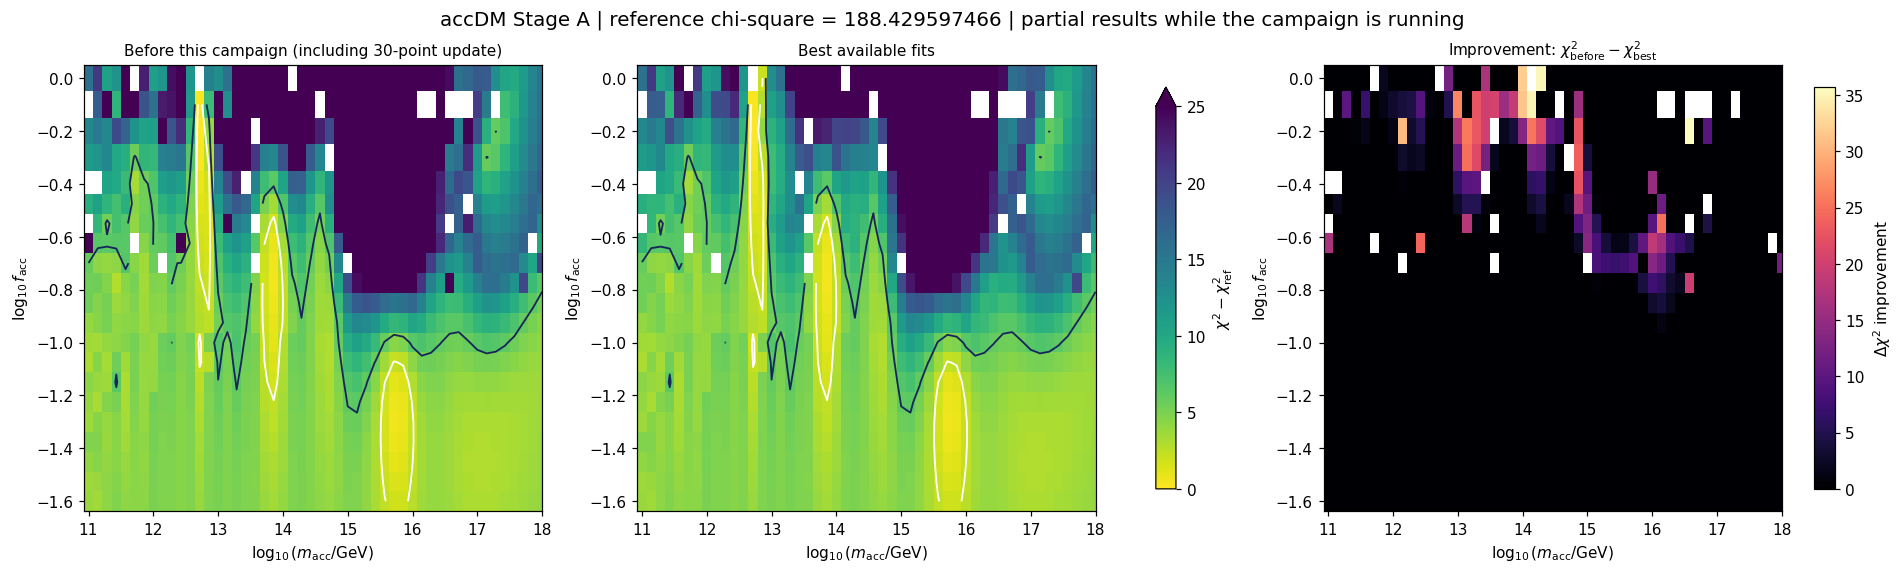

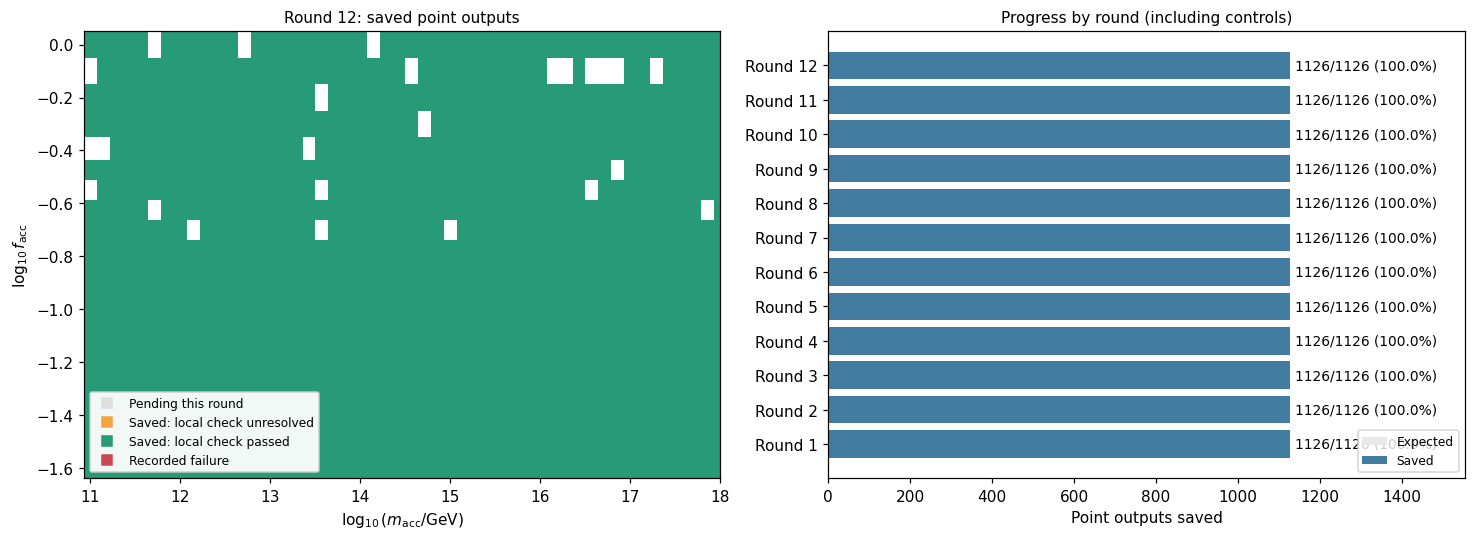

In [23]:
latest = refresh()


In [24]:
# Optional refresh button. Without ipywidgets, rerun latest = refresh().
try:
    import ipywidgets as widgets
    _refresh_button = widgets.Button(description='Refresh results', icon='refresh', button_style='info')
    _refresh_output = widgets.Output()
    def _refresh_clicked(_):
        with _refresh_output:
            clear_output(wait=True)
            refresh()
    _refresh_button.on_click(_refresh_clicked)
    display(_refresh_button, _refresh_output)
except ImportError:
    print('To update the results, rerun: latest = refresh()')


To update the results, rerun: latest = refresh()


## Largest changes and unfinished points

Tabele korzystają z ostatniego odświeżenia. `last_round` oznacza rundę ostatniego odczytanego wyniku punktu, a `solver_verified` status lokalnego sprawdzenia tego wyniku.


In [25]:
table = latest['frame'].copy()
table['gain_new_campaign'] = table.chi2_start - table.chi2_best
columns = ['coordinate_key','chi2_start','chi2_best','gain_new_campaign',
           'last_round','solver_verified','has_new_result']
display(table[table.is_target].sort_values('gain_new_campaign',ascending=False)[columns].head(20))
print('Points without any new campaign output:')
display(table[table.is_target & ~table.has_new_result][columns].head(20))


,coordinate_key,chi2_start,chi2_best,gain_new_campaign,last_round,solver_verified,has_new_result
coordinate_index,,,,,,,
16.5714285714|-0.2000000000,16.5714285714|-0.2000000000,239.256150,203.534276,35.721874,12,True,True
14.2857142857|0.0000000000,14.2857142857|0.0000000000,271.623305,236.547001,35.076303,12,True,True
14.1428571429|-0.1000000000,14.1428571429|-0.1000000000,253.452341,218.500376,34.951966,12,True,True
14.0000000000|0.0000000000,14.0000000000|0.0000000000,260.868443,228.853601,32.014843,12,True,True
14.0000000000|-0.1000000000,14.0000000000|-0.1000000000,246.939306,215.496940,31.442366,12,True,True
12.1428571429|-0.2000000000,12.1428571429|-0.2000000000,233.260140,202.574273,30.685866,12,True,True
13.0000000000|-0.1000000000,13.0000000000|-0.1000000000,225.876686,199.175364,26.701322,12,True,True
13.1428571429|-0.2000000000,13.1428571429|-0.2000000000,225.056707,199.274101,25.782606,12,True,True
14.1428571429|-0.2000000000,14.1428571429|-0.2000000000,233.833986,208.540284,25.293702,12,True,True


Points without any new campaign output:


,coordinate_key,chi2_start,chi2_best,gain_new_campaign,last_round,solver_verified,has_new_result
coordinate_index,,,,,,,


## Optional export

Ustaw `SAVE_OUTPUTS=True`, aby zapisać aktualne mapy PNG/PDF oraz tabelę CSV. Pliki mają znacznik czasu i trafiają do osobnego katalogu analiz. Nie nadpisują plików runnera.


In [26]:
SAVE_OUTPUTS = False
if SAVE_OUTPUTS:
    EXPORT_DIR.mkdir(parents=True, exist_ok=True)
    stamp = datetime.now().strftime('%Y%m%d_%H%M%S')
    for label, figure in [('maps',map_figure),('progress',progress_figure)]:
        figure.savefig(EXPORT_DIR/f'accdm_{label}_{stamp}.png',dpi=180,bbox_inches='tight')
        figure.savefig(EXPORT_DIR/f'accdm_{label}_{stamp}.pdf',bbox_inches='tight')
    latest['frame'].to_csv(EXPORT_DIR/f'accdm_available_results_{stamp}.csv',index=False)
    latest['progress'].to_csv(EXPORT_DIR/f'accdm_round_progress_{stamp}.csv',index=False)
    print('Saved to:',EXPORT_DIR)


## Optional automatic refresh

Domyślnie wyłączone, aby Run All nie zatrzymywało się na monitorowaniu. `WATCH=True` odświeża co 30 sekund przez 20 aktualizacji. Można przerwać przyciskiem Interrupt w Jupyter. Przy lokalnej kopii wyników należy niezależnie aktualizować jej zawartość z klastra.


In [27]:
WATCH = False
REFRESH_SECONDS = 30
MAX_REFRESHES = 20
if WATCH:
    for index in range(MAX_REFRESHES):
        clear_output(wait=True)
        latest = refresh()
        if index+1 < MAX_REFRESHES:
            time.sleep(max(5, REFRESH_SECONDS))
